# Balanced Portfolio Allocation with Sckit-Learn and PyTorch

I need to write more and may add more features but I need to make sure all this runs in Google collab acceptably.

I would like to visualize and add additional risk metrics such as:
- max drawdown
- upside/downside capture
- batting average
- information ratio

### Imports

These are most commonly required imports, classes may have additional libraries they rely on.

In [3]:
import pandas as pd
import numpy as np
from datetime import datetime

# from mvportfolio import MVPortfolio

In [7]:
%run mvportfolio.py # this is better when developing

### Helper Functions

These are some helper functions used to load and split the data into training and testing subsets.

In [11]:
def get_log_returns_from_csv(path, rplr='r'):
    # Using returns is better than prices for assets with a fixed price and variable return
    if(rplr == 'p'):
        # This is a csv file of prices
        raw = pd.read_csv(path, index_col=0, parse_dates=True).dropna()
        rets = rets = np.log(raw / raw.shift(1)).dropna()
    elif(rplr == 'lr'):
        # This is in case you have long returns already in csv
        rets = pd.read_csv(path, index_col=0, parse_dates=True).dropna()
    else:
        # This is preferred over prices
        raw = pd.read_csv(path, index_col=0, parse_dates=True).dropna()
        rets = np.log(1 + raw)
    return rets

def train_test_split_by_date(rets, split_date):
    training_returns = rets[:split_date]
    testing_returns = rets[split_date:]
    return training_returns, testing_returns

### Data

Normally cleaning data is a significant amount of work. In our case the data (returns) were chosen to go between two dates and the benchmark returns also go between those two dates. *The returns are Gross of fees and in Canadian dollars.* The benchmark returns are monthly early in the time series which causes a less smooth graph, but given we have over 2000 daily returns, we should be fine. This set represents real asset class returns at an investment management firm competing against a balanced benchmark consisting of:

**From Jun 2021:**
- 5% FTSE Canada 91 Day TBill Index
- 35% FTSE Canada Universe Bond 
- 15% S&P/TSX Composite
- 7.5% S&P/TSX Small Cap 
- 15% S&P 500 
- 15% MSCI ACWI ex-USA (net) 
- 7.5% MSCI ACWI Small Cap (net)

**From Oct 2016:**
- 5% FTSE Canada 91 Day Treasury Bill
- 30% FTSE Canada Universe Bond
- 5% FTSE WGBI
- 15% S&P/TSX Composite
- 7.5% S&P/TSX Small Cap
- 15% S&P 500
- 15% MSCI ACWI ex-USA (net)
- 7.5% MSCI ACWI Small Cap (net)

The code was tested with other data and should be data agnostic, but typically balanced portfolios can range from 20% bonds to 80% bonds with the classic 60:40 equity to debt ratio being most common. Up to 5% cash or near cash (T-bills) is not uncommon, but you could go higher maybe up to 20% and still be considered a balanced portfolio by some.

In [16]:
path = 'https://www.muschamp.ca/OffSite/eightAssetReturns.csv'
bm_path = 'https://www.muschamp.ca/OffSite/benchmarkReturns.csv'

In [18]:
log_returns = get_log_returns_from_csv(path)
log_returns.tail(1)

,E-EM,E-GSC,E-CLC,E-US,E-CSC,E-IE,D-CB,A-CMM
PerformanceDate,,,,,,,,
2025-12-31,0.00191,-0.00453,-0.00295,-0.00589,-0.00106,-0.00059,-0.00066,0.00006


In [20]:
len(log_returns)

2237

In [22]:
first_date = log_returns.index[0]
last_date = log_returns.index[-1]
print(f"Data is from {first_date} to {last_date}")

Data is from 2017-02-01 00:00:00 to 2025-12-31 00:00:00


**This is about eight years of data, so we'll put aside two years for later testing and use the rest for training and exploration.**

In [25]:
split_date = log_returns.index[-504] + pd.Timedelta(days=1) # This splits at two years of trading days plus one
# split_date = '2024-01-01' # This does the same thing, New Year's Day is helpfully a non-trading day.
print(split_date)

2023-12-30 00:00:00


In [27]:
training_asset_returns, testing_asset_returns = train_test_split_by_date(log_returns, split_date)

In [29]:
print(training_asset_returns.index[-1])

2023-12-29 00:00:00


In [31]:
print(testing_asset_returns.index[0])

2024-01-02 00:00:00


### We need a benchmark
This gives our balanced portfolios and algorithm something to compete against. Somethign that was chosen before assets weights were determined and something the Investing Agent is unaware of. This means the Investing Agent is benchmark agnostic but many clients are not.

In [34]:
bm_log_returns = get_log_returns_from_csv(bm_path)
bm_log_returns.tail(1)

,BM
PerformanceDate,
2025-12-31,-0.00228


In [36]:
len(bm_log_returns)

2237

In [38]:
bm_training_returns, bm_testing_returns = train_test_split_by_date(bm_log_returns, split_date)

In [40]:
print(bm_training_returns.index[-1])

2023-12-29 00:00:00


In [42]:
print(bm_testing_returns.index[0])

2024-01-02 00:00:00


**So the benchmark is the same length as the training asset returns and is split the same way.**

### Asset Returns and Correlations

These returns are published daily and calculated by State Street you can see positive correlations between Canadian Large Cap equity (E-CLC) and Canadian Small Cap equity (E-CSC) for instance. You can see how both the bond sleeve and the money market instruments are negatively correlated with the equity assets classes. Over the last few years you can see U.S. equity has done better than other asset classes.

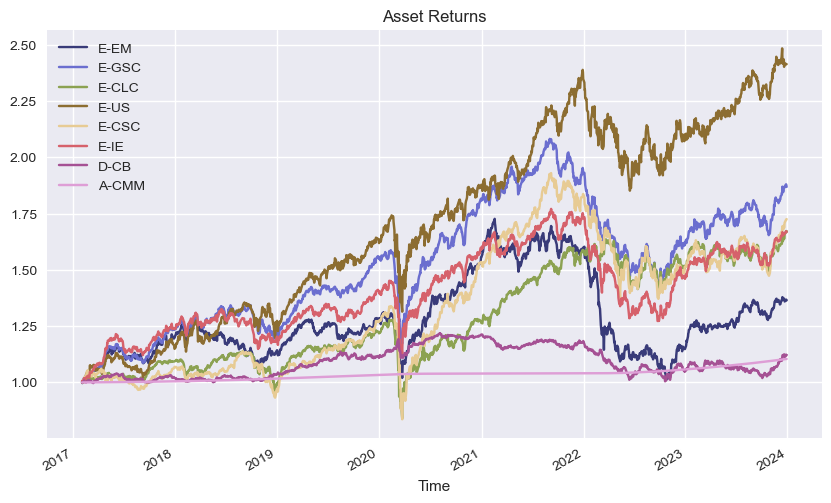

In [47]:
training_asset_returns.cumsum().apply(np.exp).plot(figsize=(10, 6), 
                                                   title="Asset Returns", 
                                                   xlabel="Time",
                                                   cmap='tab20b');

In [49]:
corr_matrix = training_asset_returns.corr()
corr_matrix.style.background_gradient(cmap='coolwarm').format(precision=4).set_caption("Asset Correlations")

,E-EM,E-GSC,E-CLC,E-US,E-CSC,E-IE,D-CB,A-CMM
E-EM,1.0000,0.5482,0.3917,0.3294,0.3960,0.6328,0.0371,-0.0267
E-GSC,0.5482,1.0000,0.6464,0.5658,0.6459,0.8503,0.1112,-0.0199
E-CLC,0.3917,0.6464,1.0000,0.7396,0.8366,0.6117,-0.0275,-0.0171
E-US,0.3294,0.5658,0.7396,1.0000,0.6255,0.5261,-0.0034,-0.0241
E-CSC,0.3960,0.6459,0.8366,0.6255,1.0000,0.5743,0.0394,-0.0207
E-IE,0.6328,0.8503,0.6117,0.5261,0.5743,1.0000,0.0981,-0.0148
D-CB,0.0371,0.1112,-0.0275,-0.0034,0.0394,0.0981,1.0000,-0.0128
A-CMM,-0.0267,-0.0199,-0.0171,-0.0241,-0.0207,-0.0148,-0.0128,1.0000


## Mean-Variance Portfolio 

My mean-variance portfolio calculating class is based on the one created during the program but is informed by how balanced portfolios are constructed and managed at our firm. We have a fixed income team that manages bonds and t-bills so most of the portfolio construction and optimization comes from setting the equity weight and choosing which equity strategies to include in the portfolio. I provide a variety of options including the ability to compare against other asset weights, compete against a benchmark, and if you choose extremely specific boundaries these can overrides the minimum and maximum individual asset weights and the target asset class weights. Setting the bounds directly allows for the most detailed testing and graphing. Only the asset level returns are required to initiate the class.

#### Balanced Portfolios
Although the classic definition of a balanced portfolio is 60% Equity and 40% Bonds, that definition is too narrow for some. At our firm a Conservative Balanced Portfolio could have closer to 80% Bonds and T-Bills and a Growth Oriented Balanced Portfolio could have up to 80% Equity. Alternative assets such as Private Equity or other illiquide assets are potentially included in custom balanced portfolios. These can be difficult to optimize for as the assets are not marked to market daily. No ill-liquid assets are included in our training and testing data sets.

#### Custom Boundaries
Limiting the algorithm's ability to assign too much of the portfolio to a single security or asset class can be simulated in infinite variety. There is only one bond sleeve so generally allowing a wider range in that sleeve is how you can simulate between 20% and 80% bonds. For equity positions a range between zero and a third of the portfolio was used extensively in testing.

#### Sample Portfolio Weights
I've included a number of arbitrary but illustrative asset weights. These include a classic 60:40 balanced portfolio which I allow to have 1% T-Bills. A 40:60 portfolio and an 80:20 portfolio are included in our training as well as a more income focused portfolio. You can use whatever weights you think are intuitive based on the returns and correlations above. Your weights ***must*** sum to 1 or you will instead get the equal weights.

An equal weight portfolio is always a good idea to test and train agaist. So I always include an equal weight portfolio so you don't need to specify one when initiating your Mean Variance Portfolio class.

In [53]:
# The boundaries aka the range of weights assignable to each asset is a key factor in algorithm asset allocation
# Boundary order EM, GSC, CLC, US, CSC, IE, CB, CMMM
custom_bnds = ((.0, .33), (.0, .33), (.0, .33), (.0, .33), (.0, .33), (.0, .33), (.19, .6), (.01, .2))

In [55]:
# We can have up to five sets of comparison portfolio weights
# Bnds are not enforced on them, but in the spirit of fairness they should 
portfolio_one_weights = (.10, .10, .10, .10, .10, .10, .39, .01) 
portfolio_one_name = 'Classic 60:40'
portfolio_two_weights = (.0659, .0659, .0659, .0659, .0659, .0659, .59, .0146) 
portfolio_two_name = 'Conservative 40:60'
portfolio_three_weights = (.133, .133, .133, .133, .133, .133, .19, .012) 
portfolio_three_name = 'Equity Growth 80:20'
portfolio_four_weights = (.05, .05, .05, .05, .05, .05, .6, .10) 
portfolio_four_name = 'Income Focused'
portfolio_five_weights = (.05, .05, .125, .125, .05, .2, .37, .03) 
portfolio_five_name = 'Intuitive Weights'

In [57]:
symbols = training_asset_returns.columns # This is the entire universe of assets, you can use a subset too
# custom_min = 0.03 # zero is default, but can be overriden
# custom_max = 0.6 # one is default, but can be overriden
# target_asset_classes = [0.6, .37, .03] # 60 equity and 40 debt is the defualt
# As we set custom_bnds above, this overrides asset class weights and min and max position size
# Setting your own custom boundaries is the most granular level of control.
training_port = MVPortfolio(
                        # min_largest_asset_class_position_size=custom_min, 
                        # max_largest_asset_class_position_size=custom_max,
                        # asset_class_weights=target_asset_classes,
                        bm_returns=bm_training_returns,
                        comparison_weights_one=portfolio_one_weights,
                        portfolio_one_name=portfolio_one_name,
                        comparison_weights_two=portfolio_two_weights,
                        portfolio_two_name=portfolio_two_name,
                        comparison_weights_three=portfolio_three_weights,
                        portfolio_three_name=portfolio_three_name,
                        comparison_weights_four=portfolio_four_weights,
                        portfolio_four_name=portfolio_four_name,
                        comparison_weights_five=portfolio_five_weights,
                        portfolio_five_name=portfolio_five_name,
                        boundaries=custom_bnds,
                        universe=training_asset_returns,
                        holdings=symbols
                       )

Remember target asset class weights [0.6, 0.4, 0.0] can be overruled by bnds.
Current bnds are ((0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.19, 0.6), (0.01, 0.2))


In [59]:
bnds_used_in_training = training_port.bnds # Good to save this for testing later
# print(bnds_used_in_training)

#### Equal Weight Portfolio Weights
The displayed weights are rounded to four decimal places but internally they are not rounded. They are floating point numbers. The equal weight portfolio ends up with 25% of the assets in bonds and money market instruments so it is on the lower end of our definition of a balanced portfolio.

In [62]:
equal_weights = training_port.equal_weights
training_port.pretty_weights(equal_weights)

+---------+--------+
| Holding | Weight |
+---------+--------+
|   E-EM  | 0.125  |
|  E-GSC  | 0.125  |
|  E-CLC  | 0.125  |
|   E-US  | 0.125  |
|  E-CSC  | 0.125  |
|   E-IE  | 0.125  |
|   D-CB  | 0.125  |
|  A-CMM  | 0.125  |
+---------+--------+


#### Minimum Risk Portfolio Weights

In [65]:
minimum_risk_weights = training_port.minimum_risk_portfolio()
training_port.pretty_weights(minimum_risk_weights)

+---------+--------+
| Holding | Weight |
+---------+--------+
|   E-EM  | 0.0817 |
|  E-GSC  | 0.034  |
|  E-CLC  | 0.0692 |
|   E-US  | 0.0051 |
|  E-CSC  |  0.0   |
|   E-IE  | 0.0099 |
|   D-CB  |  0.6   |
|  A-CMM  |  0.2   |
+---------+--------+


#### Maximum Sharpe Portfolio Weights

In [68]:
maximum_sharpe_weights = training_port.maximum_sharpe_portfolio()
training_port.pretty_weights(maximum_sharpe_weights)

+---------+--------+
| Holding | Weight |
+---------+--------+
|   E-EM  |  0.0   |
|  E-GSC  | 0.2689 |
|  E-CLC  |  0.0   |
|   E-US  | 0.1728 |
|  E-CSC  |  0.0   |
|   E-IE  |  0.0   |
|   D-CB  | 0.3583 |
|  A-CMM  |  0.2   |
+---------+--------+


#### Maximum Return portfolio weights given limits set above

In [71]:
maximum_return_weights = training_port.maximum_return_portfolio()
training_port.pretty_weights(maximum_return_weights)

+---------+--------+
| Holding | Weight |
+---------+--------+
|   E-EM  |  0.0   |
|  E-GSC  |  0.33  |
|  E-CLC  |  0.0   |
|   E-US  |  0.33  |
|  E-CSC  |  0.14  |
|   E-IE  |  0.0   |
|   D-CB  |  0.19  |
|  A-CMM  |  0.01  |
+---------+--------+


### Visualizing Portfolios
The class can calculate various portfolios relatively quickly and produces the efficient frontier given the boundaries and limits set above. The sample portfolio, equal weight portfolio, and benchmark portfolio characteristics can be compared to the maximum sharpe portfolio and minimum risk portfolio plus other asset weights you pass in.

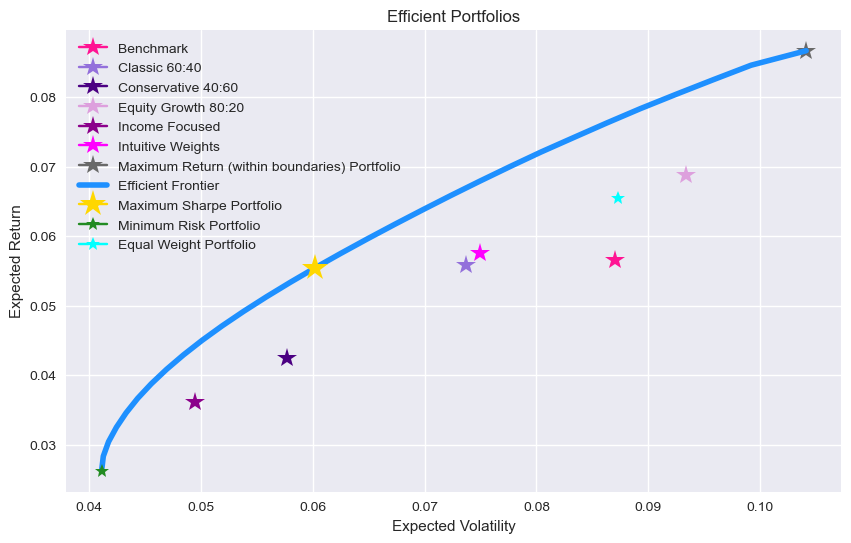

In [74]:
training_port.visualize_efficient_frontier() 

### One Year of Cummulative Equal Weight Portfolio Returns

2023-01-01 00:00:00


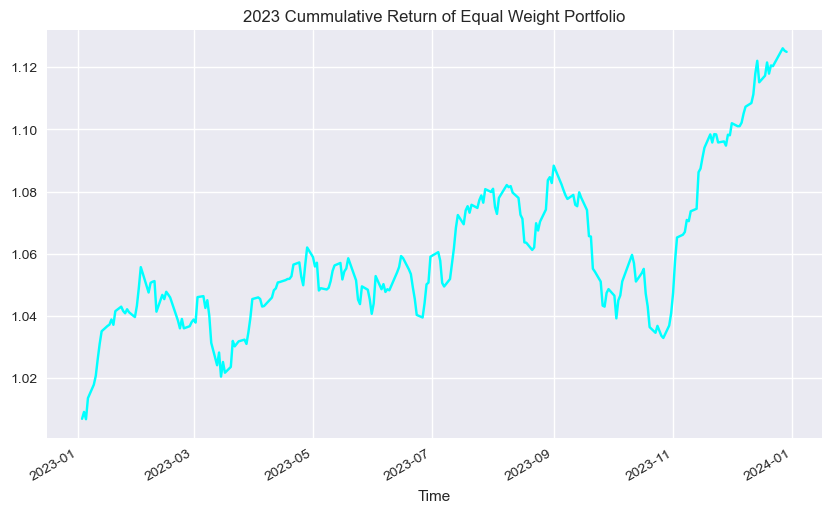

In [77]:
# period_start = '2023-01-01' # Hard coding this may not work if you change the data set
period_start = split_date + pd.Timedelta(days=-363) # This does basically the same thing
print(period_start)
cum_returns = training_port.cummulative_portfolio_returns(weights=training_port.equal_weights,
                                                          start_date=period_start, 
                                                          end_date=split_date)
cum_returns.plot(figsize=(10,6), 
                 title="2023 Cummulative Return of Equal Weight Portfolio",
                 color="cyan",
                 xlabel="Time");

### One Year of Cummulative Benchmark Returns

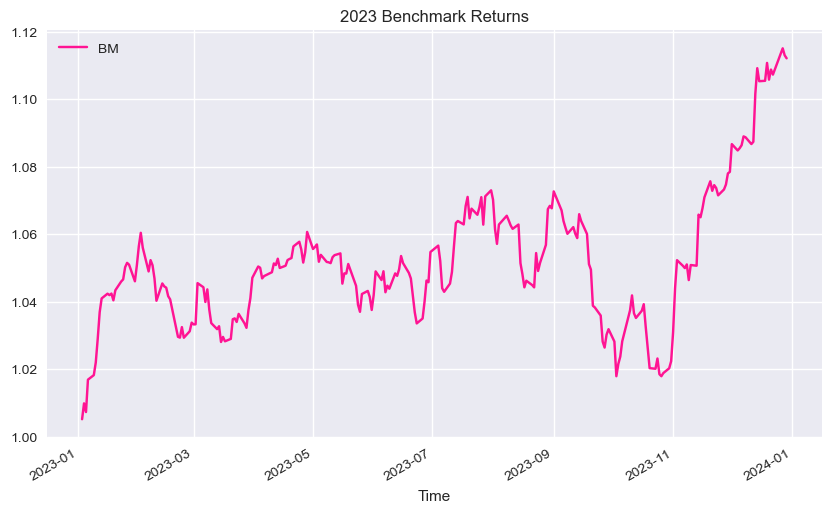

In [80]:
training_port.bm_returns[period_start:split_date].cumsum().apply(np.exp).plot(figsize=(10,6), 
                                                                              title="2023 Benchmark Returns",
                                                                              color="deeppink",
                                                                              xlabel="Time");

### Cummulative Returns of various portfolio
There is a method to visualize all the cummulative returns of various portfolios either between two dates or over the entire training period.

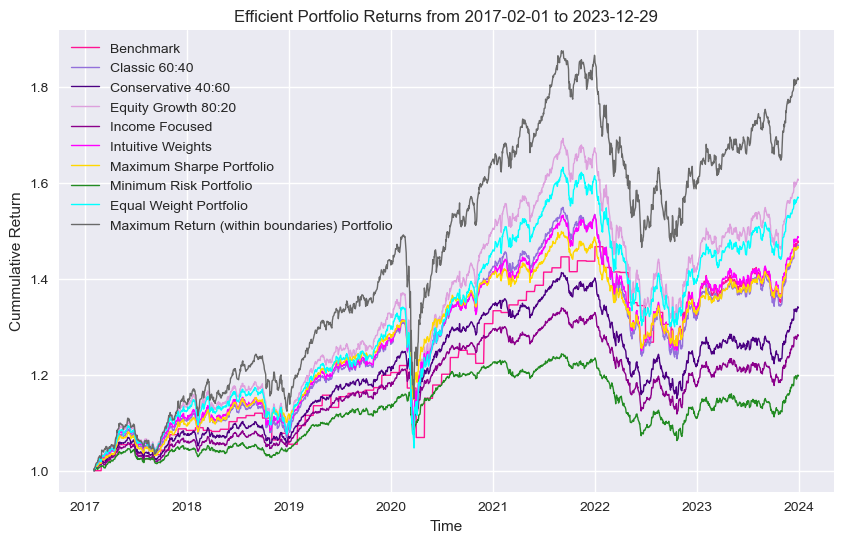

In [83]:
training_port.visualize_portfolio_returns() # Entire training period

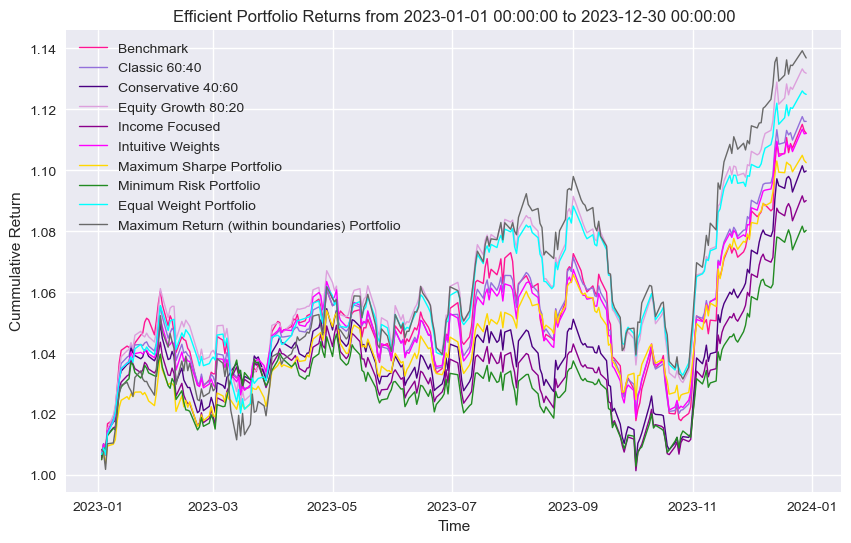

In [85]:
training_port.visualize_portfolio_returns(start_date=period_start, end_date=split_date) # One Year

#### Maximum Return Portfolio
As you can see for both the entire training period and a sample year the maximum return portfolio performs the best. This portfolio may take on more risk than a client can tolerate, but it shows the efficient frontier's accuracy.

## Calculating Annual Mean-Variance Portfolios
It is possible to split the training data into smaller subsets to get the mean-variance portfolio for individual years this is anagolous to performing annual rebalancing based on the previous year's returns. Basing your portfolio on the previous year's returns may not be as effective as choosing weights based on a longer time period, but it may prove advantageous.

In [89]:
optimal_annual_weights = training_port.annual_maximum_sharpe_portfolios()

In [91]:
training_port.pretty_annual_weights(optimal_annual_weights)

+------+---------+---------+
| Year | Holding | Weights |
+------+---------+---------+
| 2018 |   E-EM  |   0.0   |
| 2018 |  E-GSC  |   0.0   |
| 2018 |  E-CLC  |   0.0   |
| 2018 |   E-US  |   0.2   |
| 2018 |  E-CSC  |   0.0   |
| 2018 |   E-IE  |   0.0   |
| 2018 |   D-CB  |   0.6   |
| 2018 |  A-CMM  |   0.2   |
|      |         |         |
| 2019 |   E-EM  |   0.0   |
| 2019 |  E-GSC  |   0.15  |
| 2019 |  E-CLC  |   0.02  |
| 2019 |   E-US  |   0.0   |
| 2019 |  E-CSC  |   0.27  |
| 2019 |   E-IE  |   0.0   |
| 2019 |   D-CB  |   0.35  |
| 2019 |  A-CMM  |   0.2   |
|      |         |         |
| 2020 |   E-EM  |   0.17  |
| 2020 |  E-GSC  |   0.0   |
| 2020 |  E-CLC  |   0.0   |
| 2020 |   E-US  |   0.03  |
| 2020 |  E-CSC  |   0.0   |
| 2020 |   E-IE  |   0.0   |
| 2020 |   D-CB  |   0.6   |
| 2020 |  A-CMM  |   0.2   |
|      |         |         |
| 2021 |   E-EM  |   0.0   |
| 2021 |  E-GSC  |   0.0   |
| 2021 |  E-CLC  |   0.33  |
| 2021 |   E-US  |   0.18  |
| 2021 |  E-CS

### How did we do?
We can go through each complete calendar year in our training data set and see how well the previous year's mean variance portfolio would have done if we had rebalanced annually.

In [94]:
year_one = list(optimal_annual_weights)[0]
last_year = list(optimal_annual_weights)[-1]
yearly_test_results = pd.DataFrame()
for year in range(year_one, last_year):
    rets_ = training_port.our_returns[symbols].loc[f'{year}-01-01':f'{year}-12-31']
    epv = MVPortfolio.annualized_volatility(rets_, optimal_annual_weights[year])
    epr = MVPortfolio.annualized_return(rets_, optimal_annual_weights[year])
    esr = epr / epv
    rets_ = training_port.our_returns[symbols].loc[f'{year + 1}-01-01':f'{year + 1}-12-31']
    rpv = MVPortfolio.annualized_volatility(rets_, optimal_annual_weights[year])
    rpr = MVPortfolio.annualized_return(rets_, optimal_annual_weights[year])
    rsr = rpr / rpv
    yearly_test_results = pd.concat([yearly_test_results, pd.DataFrame({'Expected Portfolio Volatility': epv, 
                                                                        'Expected Portfolio Return': epr, 
                                                                        'Expected Sharpe Ratio': esr,
                                                                        'Realized Portfolio Volatility': rpv, 
                                                                        'Realized Portfolio Return': rpr, 
                                                                        'Realized Sharpe Ratio': rsr},
                                                                       index=[year + 1])])
yearly_test_results 

,Expected Portfolio Volatility,Expected Portfolio Return,Expected Sharpe Ratio,Realized Portfolio Volatility,Realized Portfolio Return,Realized Sharpe Ratio
2019,0.03543,0.03200,0.90305,0.03111,0.09286,2.98506
2020,0.03046,0.14095,4.62805,0.10489,0.10909,1.04005
2021,0.04727,0.09359,1.98008,0.03728,-0.00468,-0.12555
2022,0.06151,0.12791,2.07958,0.10040,-0.07639,-0.76081
2023,0.10391,-0.06850,-0.65930,0.05983,0.09654,1.61356


### How did we do on average?

In [97]:
yearly_test_results.mean()

Expected Portfolio Volatility    0.05571
Expected Portfolio Return        0.06519
Expected Sharpe Ratio            1.78629
Realized Portfolio Volatility    0.06670
Realized Portfolio Return        0.04348
Realized Sharpe Ratio            0.95046
dtype: float64

### Visualizing Annual Mean Variance Portfolio Predictions

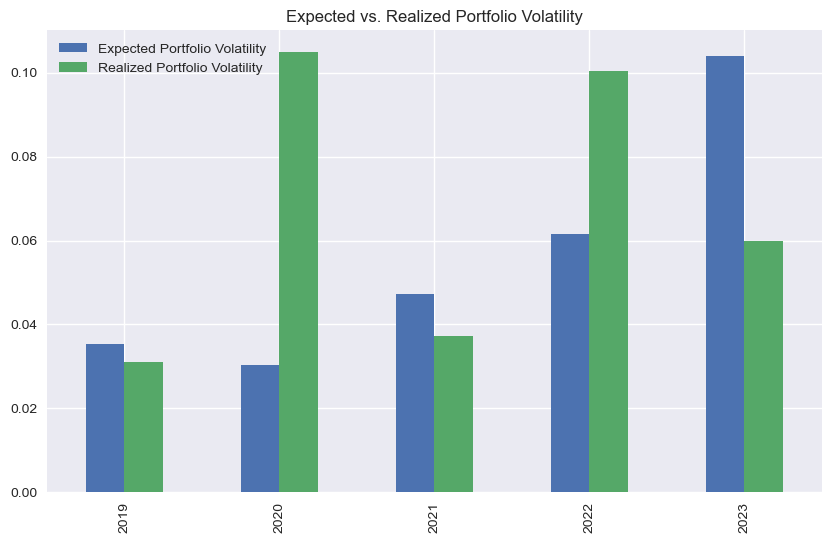

In [100]:
yearly_test_results[['Expected Portfolio Volatility', 
                     'Realized Portfolio Volatility']].plot(kind='bar', 
                                                            figsize=(10, 6),
                                                            title= 'Expected vs. Realized Portfolio Volatility');

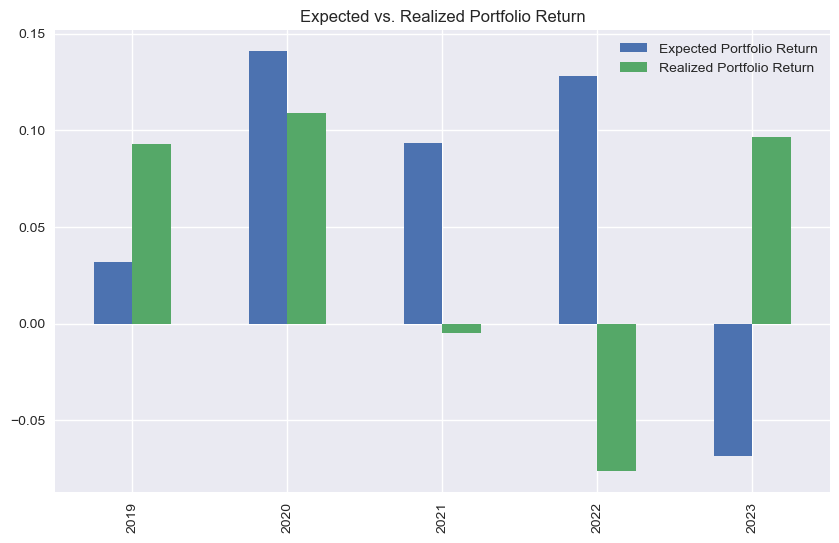

In [102]:
yearly_test_results[['Expected Portfolio Return', 
                     'Realized Portfolio Return']].plot(kind='bar', 
                                                        figsize=(10, 6),
                                                        title= 'Expected vs. Realized Portfolio Return');

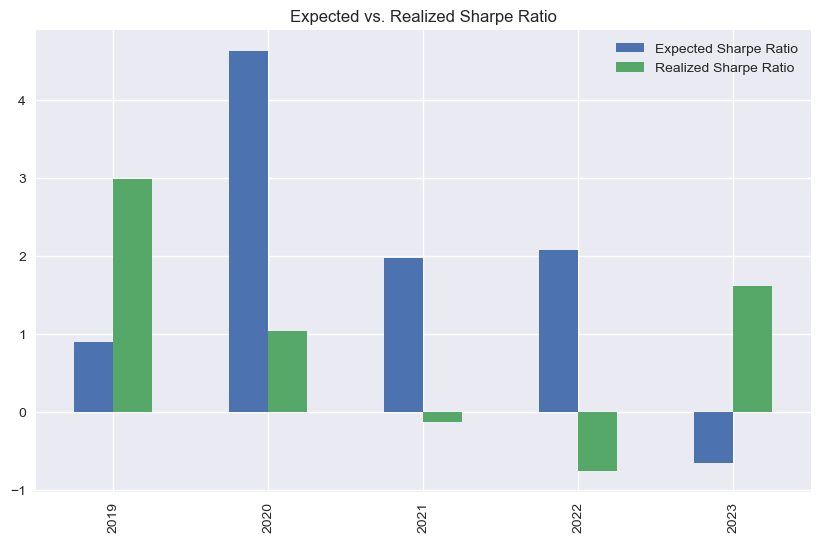

In [104]:
yearly_test_results[['Expected Sharpe Ratio', 
                     'Realized Sharpe Ratio']].plot(kind='bar', 
                                                    figsize=(10, 6),
                                                    title= 'Expected vs. Realized Sharpe Ratio');

#### Let's save the last training year's weights

In [111]:
last_training_year_weights = optimal_annual_weights[last_year]
training_port.pretty_weights(last_training_year_weights)

+---------+--------+
| Holding | Weight |
+---------+--------+
|   E-EM  | 0.3271 |
|  E-GSC  | 0.0293 |
|  E-CLC  |  0.0   |
|   E-US  | 0.1732 |
|  E-CSC  | 0.0178 |
|   E-IE  | 0.0626 |
|   D-CB  |  0.19  |
|  A-CMM  |  0.2   |
+---------+--------+


# Using Artificial Intelligence
**Is it possible to choose better portfolio weights using artificial intelligence?** Specifically we will use reinforcement learning combined with a neural network. This is known as Deep Q-Learning. The investing agent has the same goal of lowering volatility and increasing returns to achieve superior risk adjusted returns. An investing environment is set up with the same assets and boundaries affecting how much can be invested in individual assets by the Agent. *Prices are used instead of log returns and the returns are normalized as neural networks are sensitive to the scale of the data they work with.*

The Agent will be given a random set of consective daily closing prices and using that data will attempt to optimize the portfolio. In order to give the neural network more data to train and test with, we make the entire time period available but only a subset is randomly used to train the neurl network. The agent and neural network are unaware of the benchmark or the fact the money market instruments do not change in price instead the unit holder receives a distribution which is included in the returns data above.

***Let's see what the neural network can learn.***

In [114]:
%run assetallocation_pytorch.py

In [116]:
# 2 * 252 is basically two years worth of consecutive trading days, one year is faster but less accurate
days = 2 * 252 
path_to_prices = 'https://www.muschamp.ca/OffSite/eightAssetPrices.csv'
peak_at_data = pd.read_csv(path_to_prices, index_col=0, parse_dates=True).dropna()

It is always good to take a quick peak at the data. This is the publicly reported pricing data for the asset returns used above. Passing in bad data to a machine learning algorithm is unwise.

In [119]:
print(peak_at_data)

                    E-EM    E-GSC     E-CLC      E-US    E-CSC     E-IE  \
PerformanceDate                                                           
2017-02-01       10.0001  13.8781   64.2439   38.9667  75.6439  50.4614   
2017-02-02        9.9725  13.8015   64.1665   38.8121  75.6427  50.1690   
2017-02-03        9.9846  13.8622   64.4233   39.1357  76.0023  50.3045   
2017-02-06       10.0128  13.9118   64.1612   39.3404  75.7146  50.5595   
2017-02-07       10.0204  14.0113   64.4349   39.4215  75.7669  50.8886   
...                  ...      ...       ...       ...      ...      ...   
2025-12-23       18.0517  14.8941  102.5794  105.9821  95.2158  81.4786   
2025-12-24       18.0577  14.8654  102.4631  106.1113  95.1856  81.4015   
2025-12-29       18.2837  14.9313  102.3947  106.0696  95.4387  81.6705   
2025-12-30       18.3277  14.9416  102.2274  105.9301  95.0715  81.8009   
2025-12-31       18.3627  14.8741  101.9266  105.3081  94.9709  81.7530   

                    D-CB

#### Randomnesss
In order for the test to be repeatable the random seeds are set before selecting the random time periods.

In [122]:
# Some people really like to use 42
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

### Investing environment
This is the simulated enviroment the agent operates in.

In [125]:
investing = Investing(steps=days,
                      path=path_to_prices, 
                      holdings=symbols
                     ) 

Data is a random chunk of consecutive training days. The returns are normalized and index position zero will always be 1.0, the value of the assets on the last trading day in the data set is shown below.

In [128]:
investing.data.iloc[-1] 

E-EM     1.25822
E-GSC    1.10789
E-CLC    1.01179
E-US     1.21834
E-CSC    1.05364
E-IE     1.18267
D-CB     0.95188
A-CMM    1.00000
Name: 2024-04-30 00:00:00, dtype: float64

### Investing Agent
This is anagolous to the manager of the portfolio, given the data available the agent will try to allocate the portfolio to the available assets within the bounds they are given in order maximize return and minimize risk. The agent is trained on several random samples then gets an opportunity to prove they learned and developed their neural network sucessfully as they are given more and more random samples of consecutive trading days. This is a much more active management that most human managers would use, but it is all simulated by a computer in minutes. In order to constrain the agent there is a cost to changing the weights excessively. The Mean Square Error is used for this penalty. There are various hyperparmaters that can be adjusted to try and produce an agent which optimally allocates the portfolio. 

Features scale with the number of assets in the investing universe. One hundred and twenty-eight was chosen to be the hidden units (dimension) for each hidden layer of the neural network and the learning rate controls the speed at which the agent learns. It is possible to pass in starting weights for the optimizer to use instead of using the equal weights *which is the default*. You can also linearly scale the penalty applied for changing weights. **Increasing this makes it more expensive for the Agent to change asset weights extremely.**

In [131]:
our_features = investing.noa * 2 # We allocate two features per asset, this is important not to change.
agent = InvestingAgent('NAC', 
                       feature=None, 
                       n_features=our_features,
                       env=investing, 
                       boundaries=bnds_used_in_training,
                       starting_weights=portfolio_five_weights, # Passing in weights can speed up the Agent converging
                       penalty_scaling_factor=2, # You can adjust this and learning rate
                       hu=128, # The size of the hidden layer, this is an important hyperparameter.
                       lr=0.000001) 

#### Training Episodes
Generally more training is better but there are diminishing returns given the size of our neural network, test data set and compute available. 

In [134]:
episodes = 80 # Definitely want more than two, 80 is lots when demoing

In [136]:
%time agent.learn(episodes) 

Episode=   1 | Total Reward=  4.465 | Max=  4.465
Episode=   2 | Total Reward=  5.098 | Max=  5.098
Episode=   3 | Total Reward=  0.318 | Max=  5.098
Episode=   4 | Total Reward=  6.998 | Max=  6.998
Episode=   5 | Total Reward= -0.948 | Max=  6.998
Episode=   6 | Total Reward= -1.428 | Max=  6.998
Episode=   7 | Total Reward=  7.010 | Max=  7.010
Episode=   8 | Total Reward=  8.267 | Max=  8.267
Episode=   9 | Total Reward=  7.651 | Max=  8.267
Episode=  10 | Total Reward=  5.931 | Max=  8.267
Episode=  11 | Total Reward=  8.408 | Max=  8.408
Episode=  12 | Total Reward=  6.693 | Max=  8.408
Episode=  13 | Total Reward= 10.373 | Max= 10.373
Episode=  14 | Total Reward=  2.879 | Max= 10.373
Episode=  15 | Total Reward=  8.845 | Max= 10.373
Episode=  16 | Total Reward=  6.765 | Max= 10.373
Episode=  17 | Total Reward=  8.453 | Max= 10.373
Episode=  18 | Total Reward=  2.389 | Max= 10.373
Episode=  19 | Total Reward=  7.872 | Max= 10.373
Episode=  20 | Total Reward= -1.454 | Max= 10.373


#### Epsilon
This is a measure of how much exploration of the environment is done versus exploiting the learning the agent has already developed. We are doing **Epsilon-Greedy Q-learning**. There is no optimal number it depends on the data and the hyperparameters and neural network design and construction.

In [139]:
# Usually we end up around .81 after 80 training episodes. Hyperparameters besides epsidoes have little effect.
agent.epsilon 

0.8185257542796961

In [141]:
agent.env.portfolios = pd.DataFrame() # Replace training portfolios, save system resources

#### Testing Epochs
After training you test your Agent again on randomly sampled consective trading days.

In [144]:
%time agent.test(20) # 80% training, 20% testing is pretty standard practice

Episode=20 | Total Reward=2.333
CPU times: user 38.3 s, sys: 616 ms, total: 38.9 s
Wall time: 44.5 s


#### Miscellaneous Code and Helper Functions
This code that makes it easier to test and demonstrate the effectiveness of the Agent.

In [147]:
weight_list = []
symbol_list_plus_pv = []
counter = 1
for symbol in symbols:
    weight_column = "weight_" + symbol
    weight_list.append(weight_column)
    symbol_list_plus_pv.append(symbol)
    counter += 1

symbol_list_plus_pv.append('pv')
# print(weight_list)
# print(symbol_list_plus_pv)

def get_r(n):
    r = agent.env.portfolios[
        agent.env.portfolios['e'] == n
        ].set_index('date')
    return r

# This one may need to be moved lower
def calculate_sr():
    for n in set(investing.portfolios['e']):
        r = get_r(n)
        sub = r[symbol_list_plus_pv]
        rets = sub.iloc[-1] / sub.iloc[0] - 1
        stds = sub.pct_change().std() * math.sqrt(252)
        sharpe_ratios[n] = rets / stds

### Examining the Agent Test Results

First we look at the average weight the Agent assigned to each of our assets.

In [151]:
average_ml_weight_table = agent.env.portfolios.groupby('e')[weight_list].mean().mean()
ml_average_weights = average_ml_weight_table.to_list()
average_ml_weight_table.round(2) # Don't pass rounded values to methods

weight_E-EM     0.04
weight_E-GSC    0.33
weight_E-CLC    0.12
weight_E-US     0.00
weight_E-CSC    0.00
weight_E-IE     0.01
weight_D-CB     0.32
weight_A-CMM    0.18
dtype: float64

We can also look at the average value of the portfolio and assets over an episode.

In [154]:
agent.env.portfolios.groupby('e')[symbol_list_plus_pv].last().mean().round(2) # Final testing episode

E-EM     1.19
E-GSC    1.06
E-CLC    1.15
E-US     1.29
E-CSC    1.19
E-IE     1.14
D-CB     0.99
A-CMM    1.00
pv       1.00
dtype: float64

We can also look at the ending portfolio value with **bigger of course being better**.

In [157]:
agent.env.portfolios.groupby('e')['pv'].last()

e
81     0.83512
82     0.99952
83     1.08697
84     1.04603
85     1.04612
86     0.88682
87     0.99958
88     0.98414
89     1.08056
90     1.02447
91     1.09973
92     0.98966
93     0.85601
94     1.02340
95     0.98140
96     0.99236
97     1.01692
98     1.01426
99     1.03252
100    1.05606
Name: pv, dtype: float64

### Reviewing an Individual Episode
We can select select an individual episode and examine it further. In order for the testing to be repeatable we select the same episode here, but you can choose another one if you prefer. 

In [160]:
# This code won't work for sample size one training and sample size one testing episode.
episode_number = min(agent.env.portfolios['e']) + 10 # This gets a predetrimined testing episode number 91.
episode_number 

91

In [162]:
r = get_r(episode_number)
episode_start_date = r['e'].index[0] # .date[0]
print("Episode", episode_number, "Start Date:", episode_start_date)
episode_end_date = r['e'].index[-1] #.date[0]
print("Episode", episode_number, "End Date:", episode_end_date)

Episode 91 Start Date: 2023-10-12 00:00:00
Episode 91 End Date: 2025-10-14 00:00:00


#### Asset Weights used in the Episode

Examining the weights reveals the neural network has a strong preference for certain asset classes and others it quickly assigns the minimum weight it is allowed to assign. Also the best performance is often in a period where the markets were increasing greatly or volatile. In this data set there are two volatile periods where the market declined sharply during Russia's initial invasion of Ukraine in early 2020 and President Donald Trump's Liberation Day in April of 2025.

In [165]:
r[weight_list].describe().round(2)

,weight_E-EM,weight_E-GSC,weight_E-CLC,weight_E-US,weight_E-CSC,weight_E-IE,weight_D-CB,weight_A-CMM
count,503.00,503.00,503.00,503.0,503.00,503.00,503.00,503.00
mean,0.05,0.33,0.03,0.0,0.00,0.00,0.40,0.19
std,0.05,0.01,0.05,0.0,0.01,0.02,0.07,0.02
min,0.00,0.22,0.00,0.0,0.00,0.00,0.19,0.09
25%,0.00,0.33,0.00,0.0,0.00,0.00,0.36,0.20
50%,0.04,0.33,0.00,0.0,0.00,0.00,0.41,0.20
75%,0.10,0.33,0.02,0.0,0.00,0.00,0.47,0.20
max,0.16,0.33,0.21,0.0,0.10,0.10,0.48,0.20


We can review the average allocation to the various assets used in this episode.

In [168]:
r[weight_list].mean().round(4) 

weight_E-EM     0.0514
weight_E-GSC    0.3293
weight_E-CLC    0.0263
weight_E-US     0.0000
weight_E-CSC    0.0007
weight_E-IE     0.0038
weight_D-CB     0.3975
weight_A-CMM    0.1909
dtype: float64

We can also compute the standard deviation to get an idea of how much the Agent changed the weights during this episode.

In [171]:
r[weight_list].std().round(4)

weight_E-EM     0.0507
weight_E-GSC    0.0071
weight_E-CLC    0.0550
weight_E-US     0.0000
weight_E-CSC    0.0073
weight_E-IE     0.0156
weight_D-CB     0.0693
weight_A-CMM    0.0227
dtype: float64

We can graph the path the Agent took in allocating the portfolio in order to their best asset allocation during the episode.

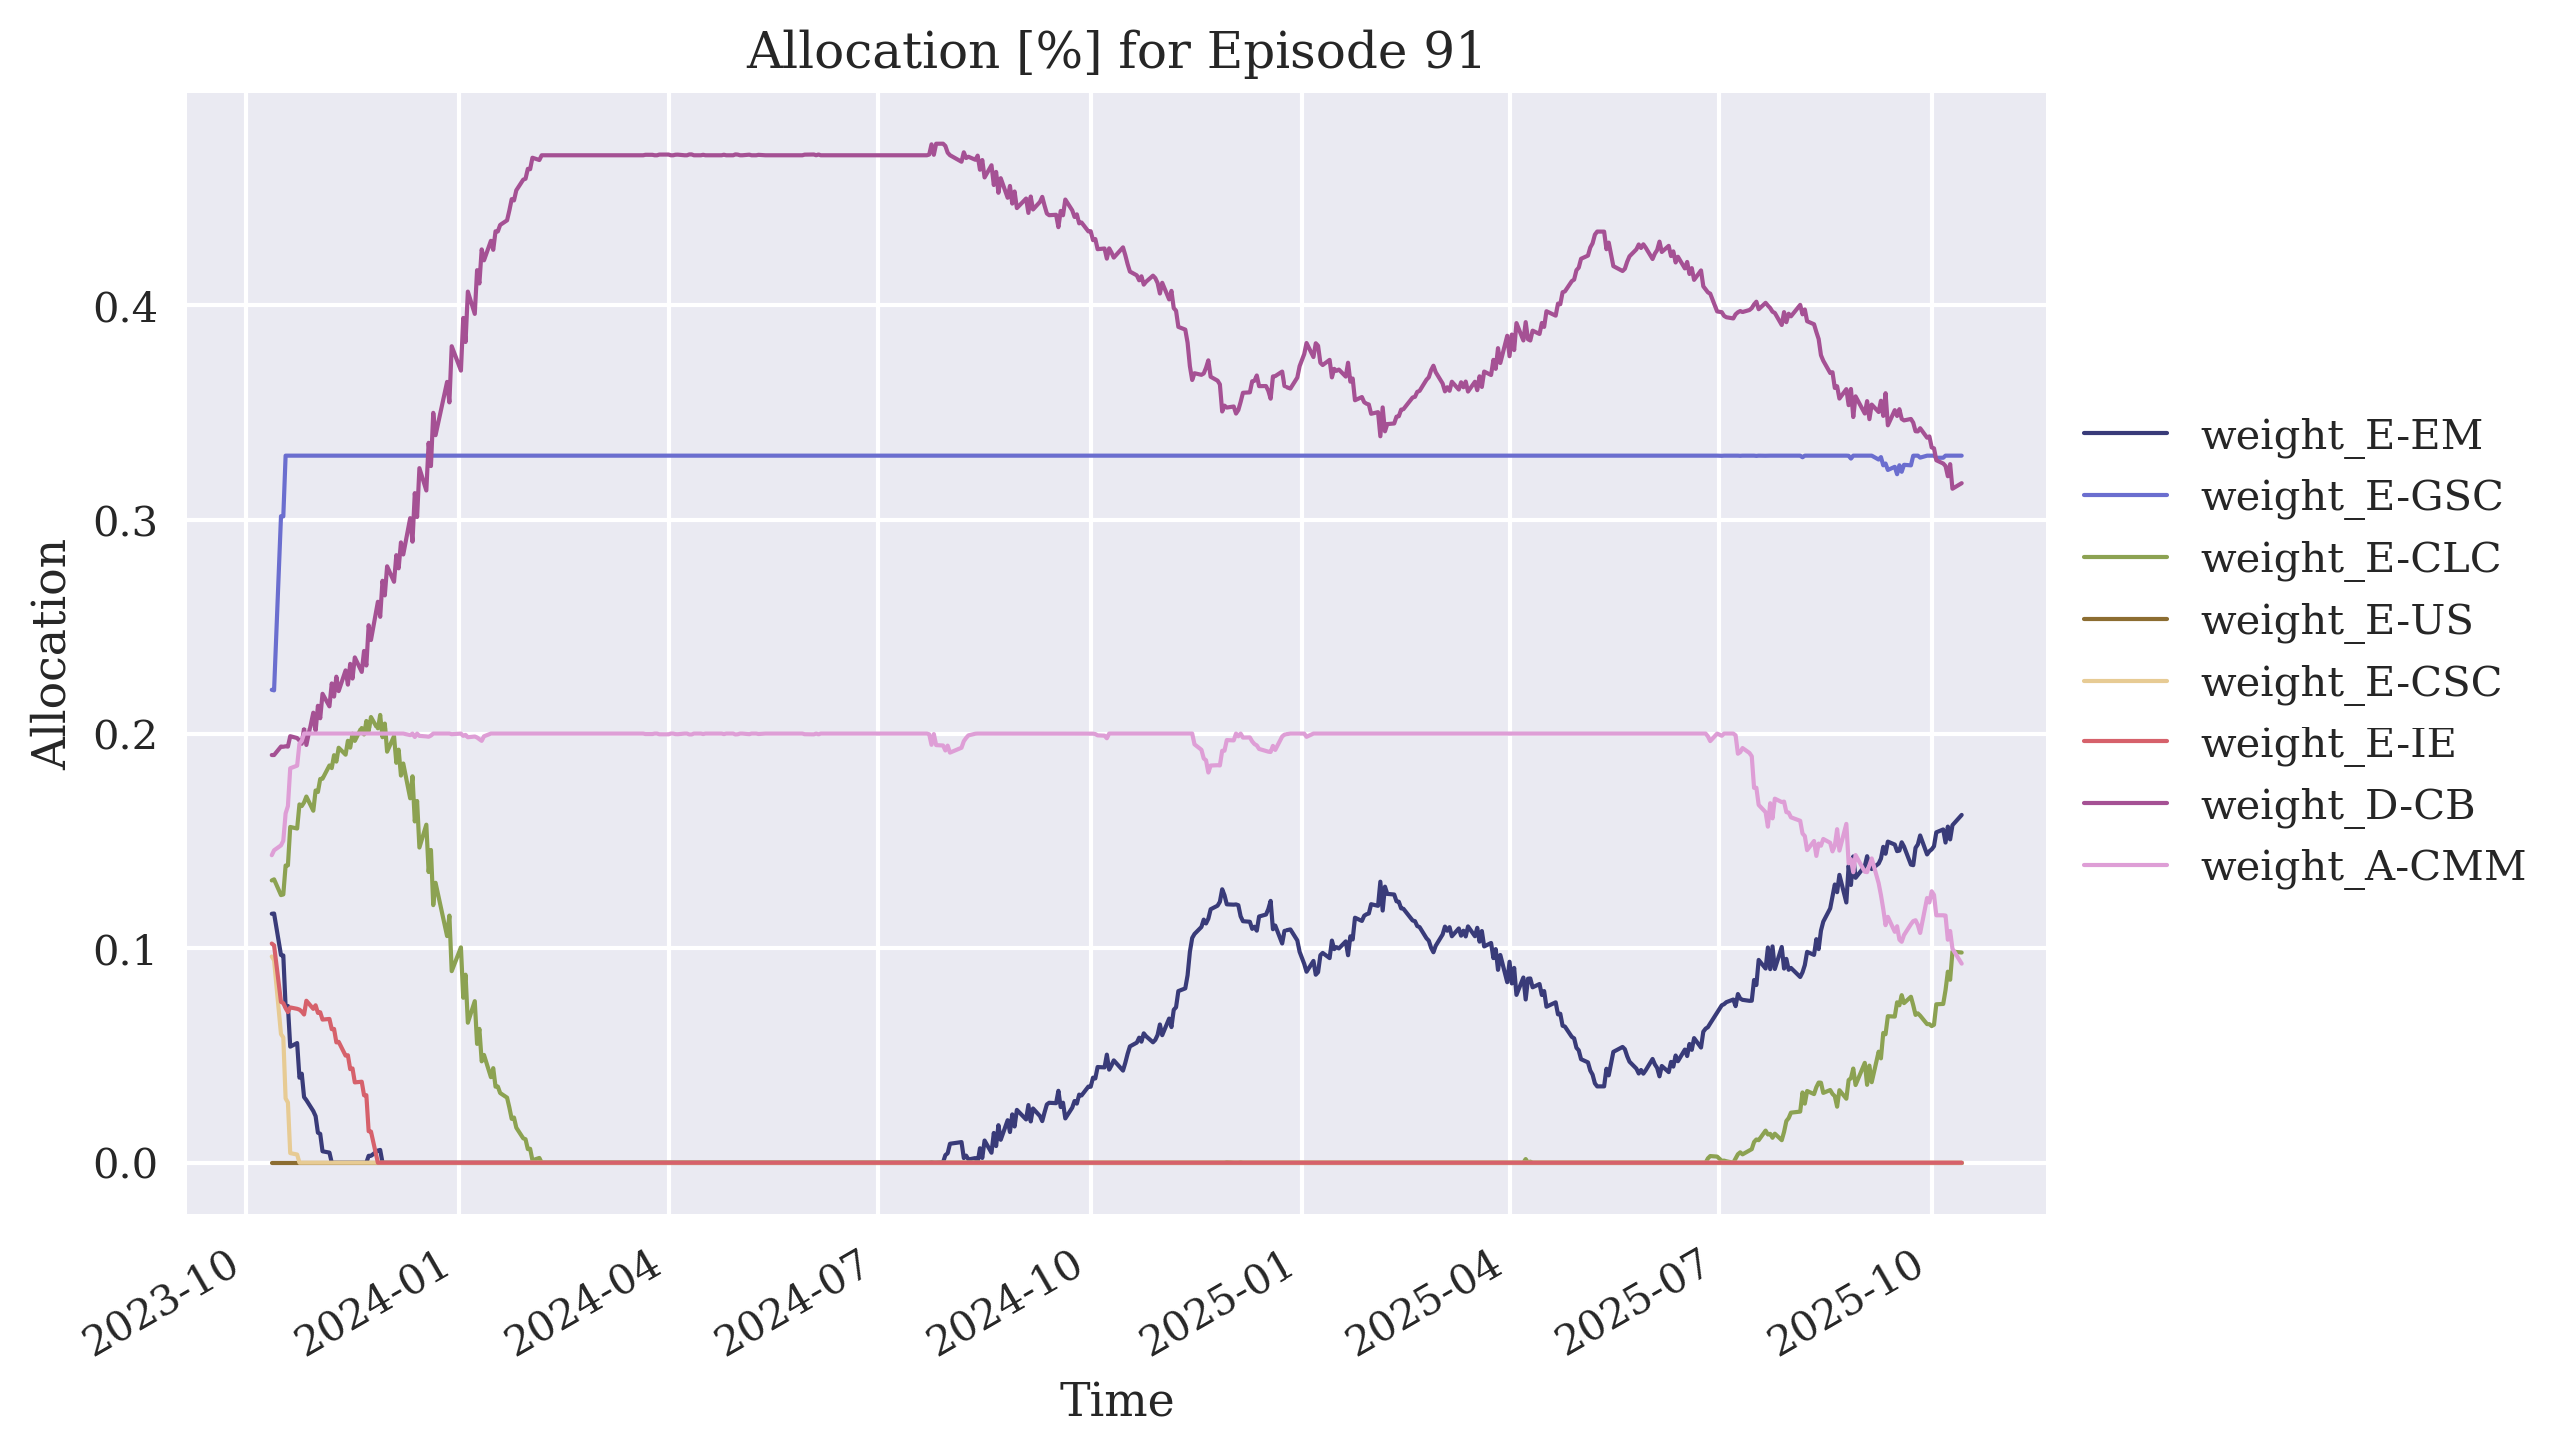

In [174]:
graph_tile = 'Allocation [%] for Episode ' + str(episode_number)
r[weight_list].plot(
    title=graph_tile,
    lw=1,
    cmap='tab20b',
    grid=True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Time')
plt.ylabel('Allocation');

#### Testing Episode Asset Correlation
Does the Agent prefer Global Small Cap because of how correlated with fixed income (D-CB) and t-bills (A-CMM) it is? That was a pet theory I had, so I decided to indulge myself with a peak at the returns during this episode.

In [187]:
ep_corr_matrix = log_returns[episode_start_date:episode_end_date].corr()
ep_corr_matrix.style.background_gradient(cmap='coolwarm').format(precision=4).set_caption("Episode Asset Correlations")

,E-EM,E-GSC,E-CLC,E-US,E-CSC,E-IE,D-CB,A-CMM
E-EM,1.0000,0.4999,0.2562,0.2100,0.2514,0.6195,0.0616,-0.0250
E-GSC,0.4999,1.0000,0.5034,0.3652,0.4652,0.7496,0.2356,-0.0048
E-CLC,0.2562,0.5034,1.0000,0.6834,0.8207,0.3551,0.1565,0.0306
E-US,0.2100,0.3652,0.6834,1.0000,0.5779,0.2322,0.1492,0.0178
E-CSC,0.2514,0.4652,0.8207,0.5779,1.0000,0.2589,0.1122,-0.0037
E-IE,0.6195,0.7496,0.3551,0.2322,0.2589,1.0000,0.1696,0.0055
D-CB,0.0616,0.2356,0.1565,0.1492,0.1122,0.1696,1.0000,0.0359
A-CMM,-0.0250,-0.0048,0.0306,0.0178,-0.0037,0.0055,0.0359,1.0000


So the episode correlation between GSC, CB, and CMM may be a factor, but once trained the neural network used by the Agent becomes something of a black box. Fixed Income and Money Market are the two lowest correlations with Global Small Cap equity over our entire period of data.

### Commentary & Analysis
The Agent starts at the intuitive weights but then immediately adds more money market units which have no volatility then gradually adds bonds selling off their Canadian Large Cap equity. Then after maxing out bonds the Agent gradually lowers the fixed income weight while increasing the Emerging Market Equity weight. The agent based on our training has a *strong preference* for Global Small Cap equity and will almost always max out in this asset class. Eventually the Agent sells some of their t-bills and buys Canadian Large Cap equity which seems to be his second or third favourite equity sleeve. The agent seems to have a preference for the riskies and least risky assets classes.

**Changing the penalty term** changes the speed and extremeness of the Agent's rebalancing efforts but the Agent always reverts to what they learned during training.

In [191]:
subset = r[symbol_list_plus_pv]
machine_learning_returns = subset.iloc[-1] / subset.iloc[0] - 1 # not scaled to one year this is end / beg value minus 1
machine_learning_returns

E-EM     0.61497
E-GSC    0.11549
E-CLC    0.34446
E-US     0.33449
E-CSC    0.25346
E-IE     0.44357
D-CB     0.08194
A-CMM    0.00000
pv       0.09973
dtype: float64

In [193]:
machine_learning_stdevs = subset.pct_change().std() * math.sqrt(252)
machine_learning_stdevs

E-EM     0.12230
E-GSC    0.12583
E-CLC    0.12189
E-US     0.12746
E-CSC    0.15079
E-IE     0.11442
D-CB     0.05769
A-CMM    0.00000
pv       0.05845
dtype: float64

We can compute the sharpe ratio which is what the agent was trying to optimize for.

In [196]:
machine_learning_returns / machine_learning_stdevs

E-EM     5.02832
E-GSC    0.91789
E-CLC    2.82600
E-US     2.62429
E-CSC    1.68084
E-IE     3.87672
D-CB     1.42029
A-CMM        NaN
pv       1.70637
dtype: float64

As we used prices, the Money Market sleeve never changes price, it distributes money daily but the agent doesn't know that. However the Agent seems to grasp that this is the least volatile asset class and the safest place to part money in tumultous market. But the lack of changing prices is why it is NaN.

#### Graph of Asset and Portfolio Values

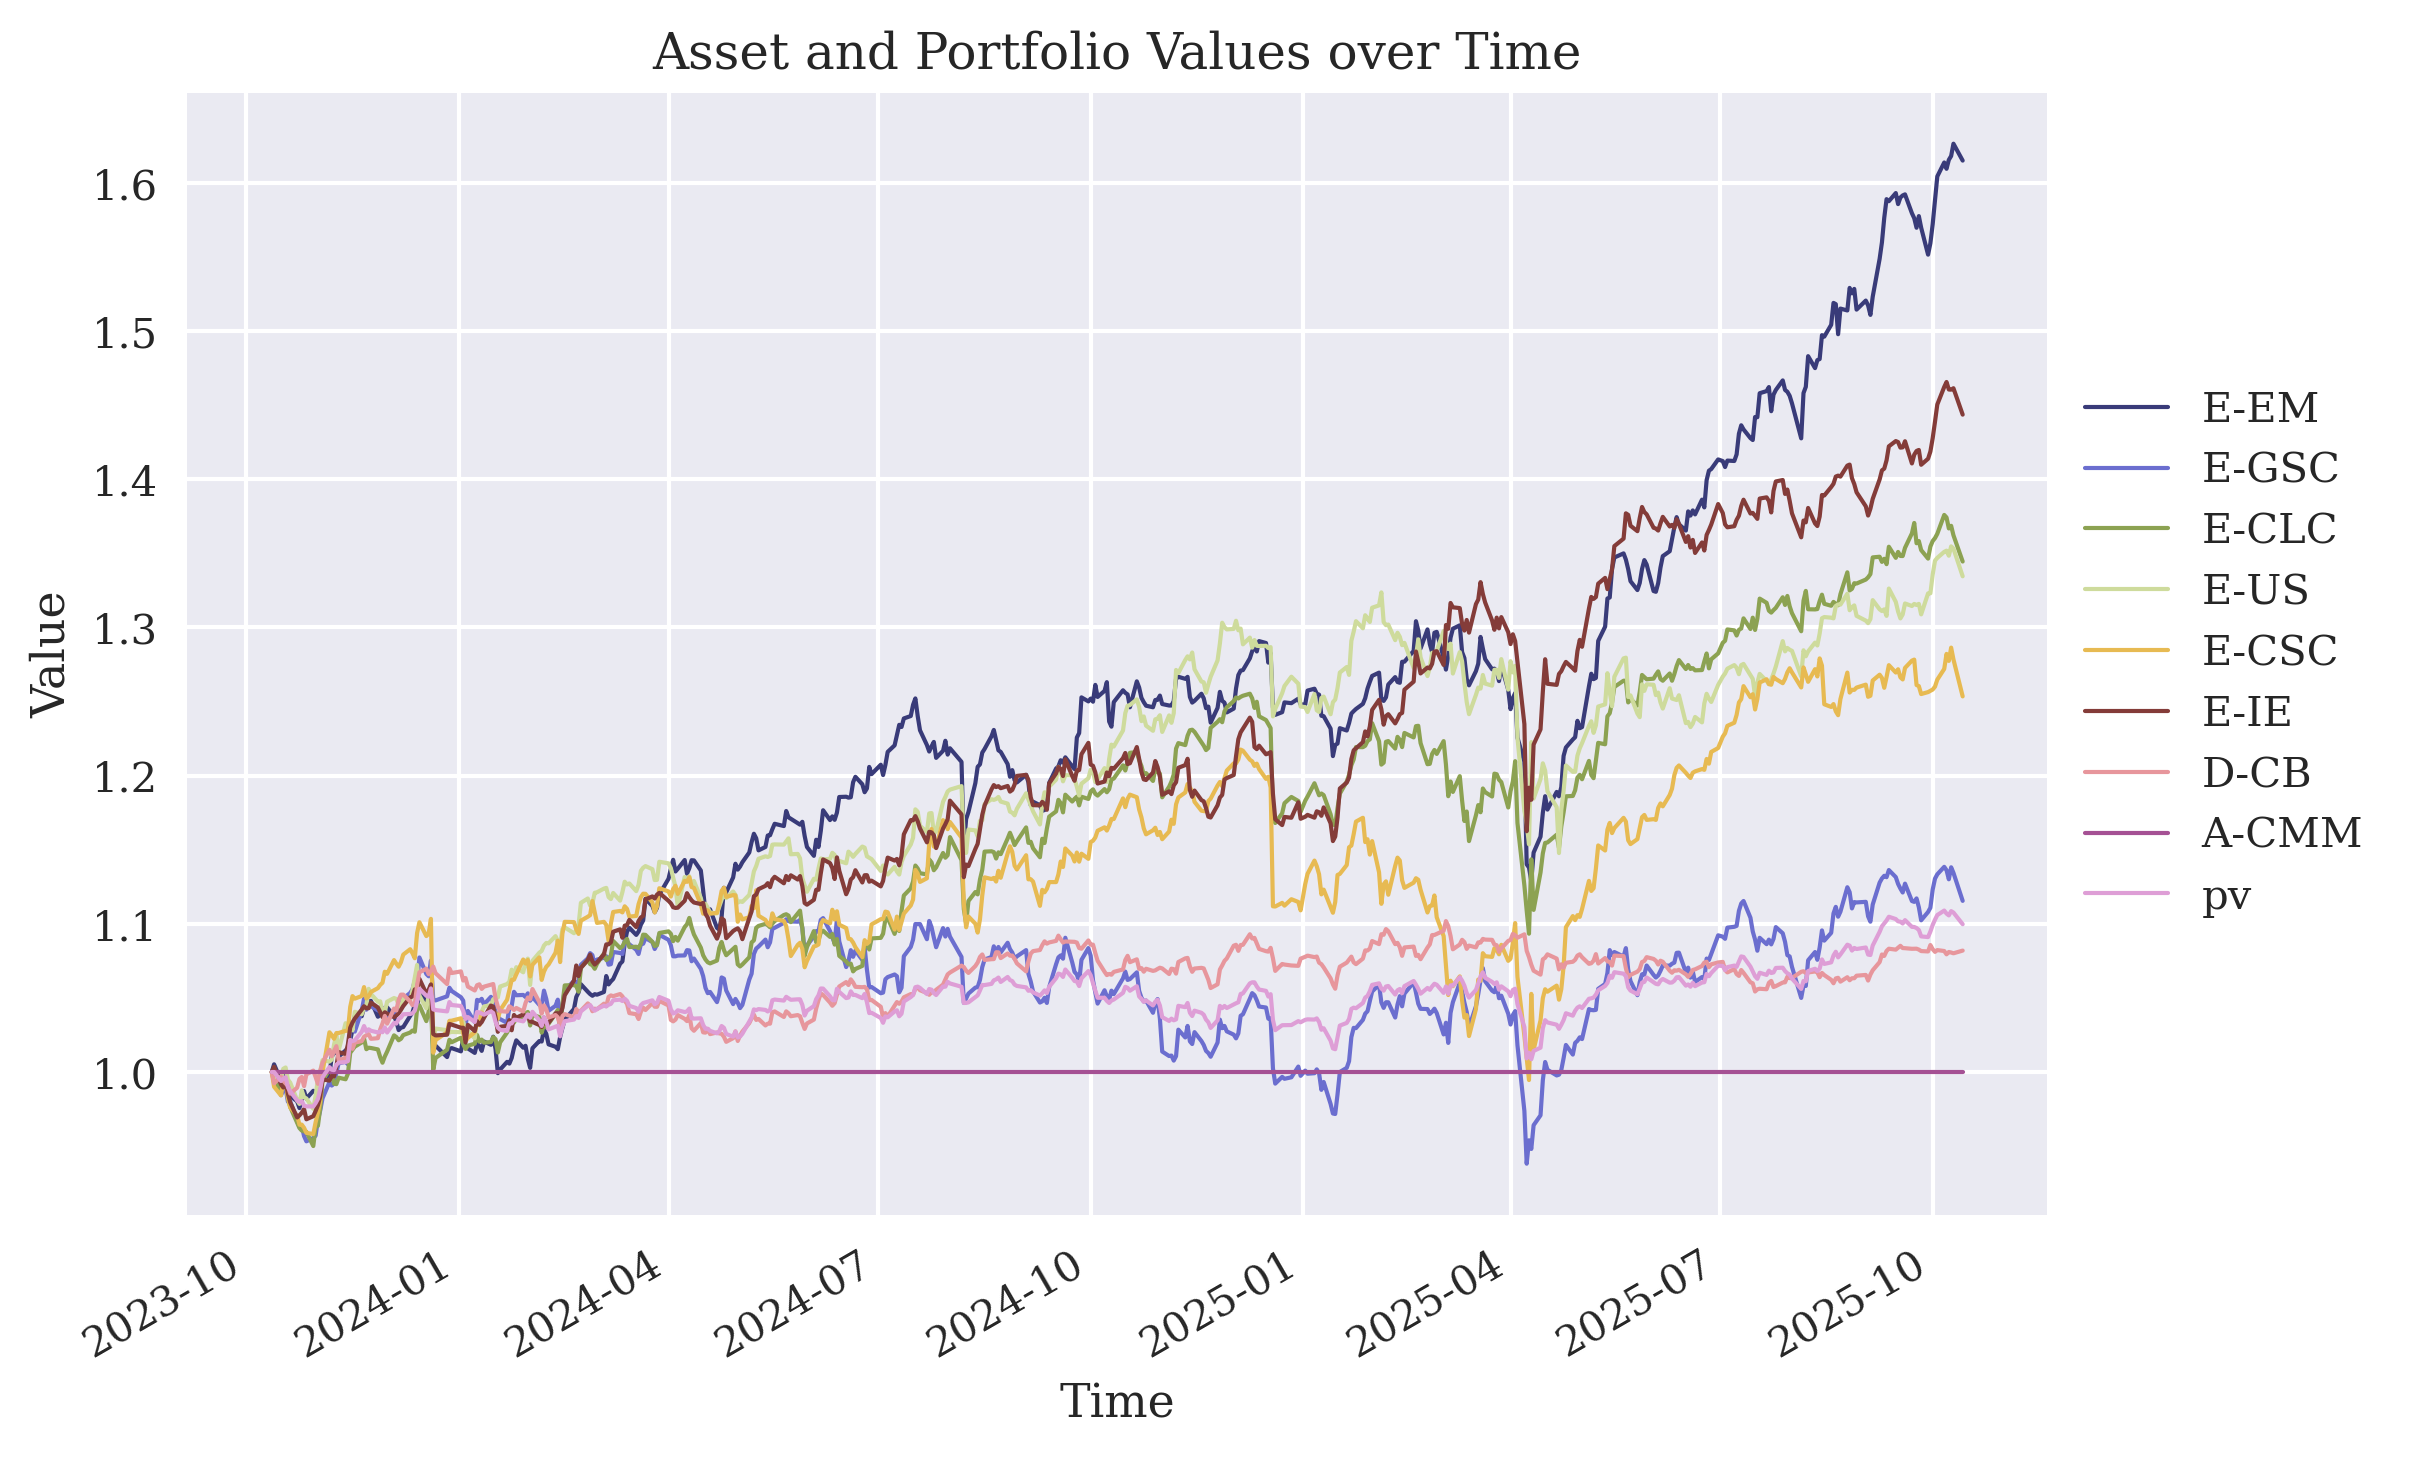

In [201]:
subset.plot(lw=1, title='Asset and Portfolio Values over Time', cmap='tab20b')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel('Value')
plt.xlabel('Time');

#### Machine Learning Portfolio vs Benchmark
Let's get some benchmark data to compare with this episode's performance.

In [204]:
# cummulative_bm_returns = (1 + bm_log_returns[episode_start_date:episode_end_date]).cumprod()
# This is how I did it above let's be consistent
cummulative_bm_returns = bm_log_returns[episode_start_date:episode_end_date].cumsum().apply(np.exp) 
cummulative_bm_returns.iloc[-1] # last value

BM    1.40616
Name: 2025-10-14 00:00:00, dtype: float64

In [206]:
cummulative_bm_returns.loc[episode_start_date] # first value

BM    0.99493
Name: 2023-10-12 00:00:00, dtype: float64

In [208]:
cummulative_bm_returns.count()

BM    504
dtype: int64

As some of the benchmark data is monthly, it is possible there are not exactly the same number of benchmark returns as episode portfolio returns, this is fine when graphing and comparing cummulative returns. Another reason for the difference is the holiday schedule used by MSCI, S&P, Russell etc. So sometimes a benchmark provider will not calculate the benchmark even though a market is open and vice versa.

In [211]:
subset.count().mean()

503.0

In [213]:
subset['BM'] = cummulative_bm_returns # Add the benchmark returns to the episode
subset = subset.dropna()
subset.tail()

,E-EM,E-GSC,E-CLC,E-US,E-CSC,E-IE,D-CB,A-CMM,pv,BM
date,,,,,,,,,,
2025-10-07,1.60943,1.13617,1.37419,1.35178,1.28212,1.46559,1.07942,1.0,1.10691,1.40495
2025-10-08,1.61548,1.13003,1.36679,1.34838,1.27738,1.46051,1.08100,1.0,1.10568,1.40967
2025-10-09,1.61807,1.13815,1.36855,1.35467,1.28635,1.46043,1.08064,1.0,1.10856,1.40650
2025-10-10,1.62637,1.13440,1.36218,1.35318,1.27839,1.46138,1.08011,1.0,1.10761,1.39222
2025-10-14,1.61497,1.11549,1.34446,1.33449,1.25346,1.44357,1.08194,1.0,1.09973,1.40616


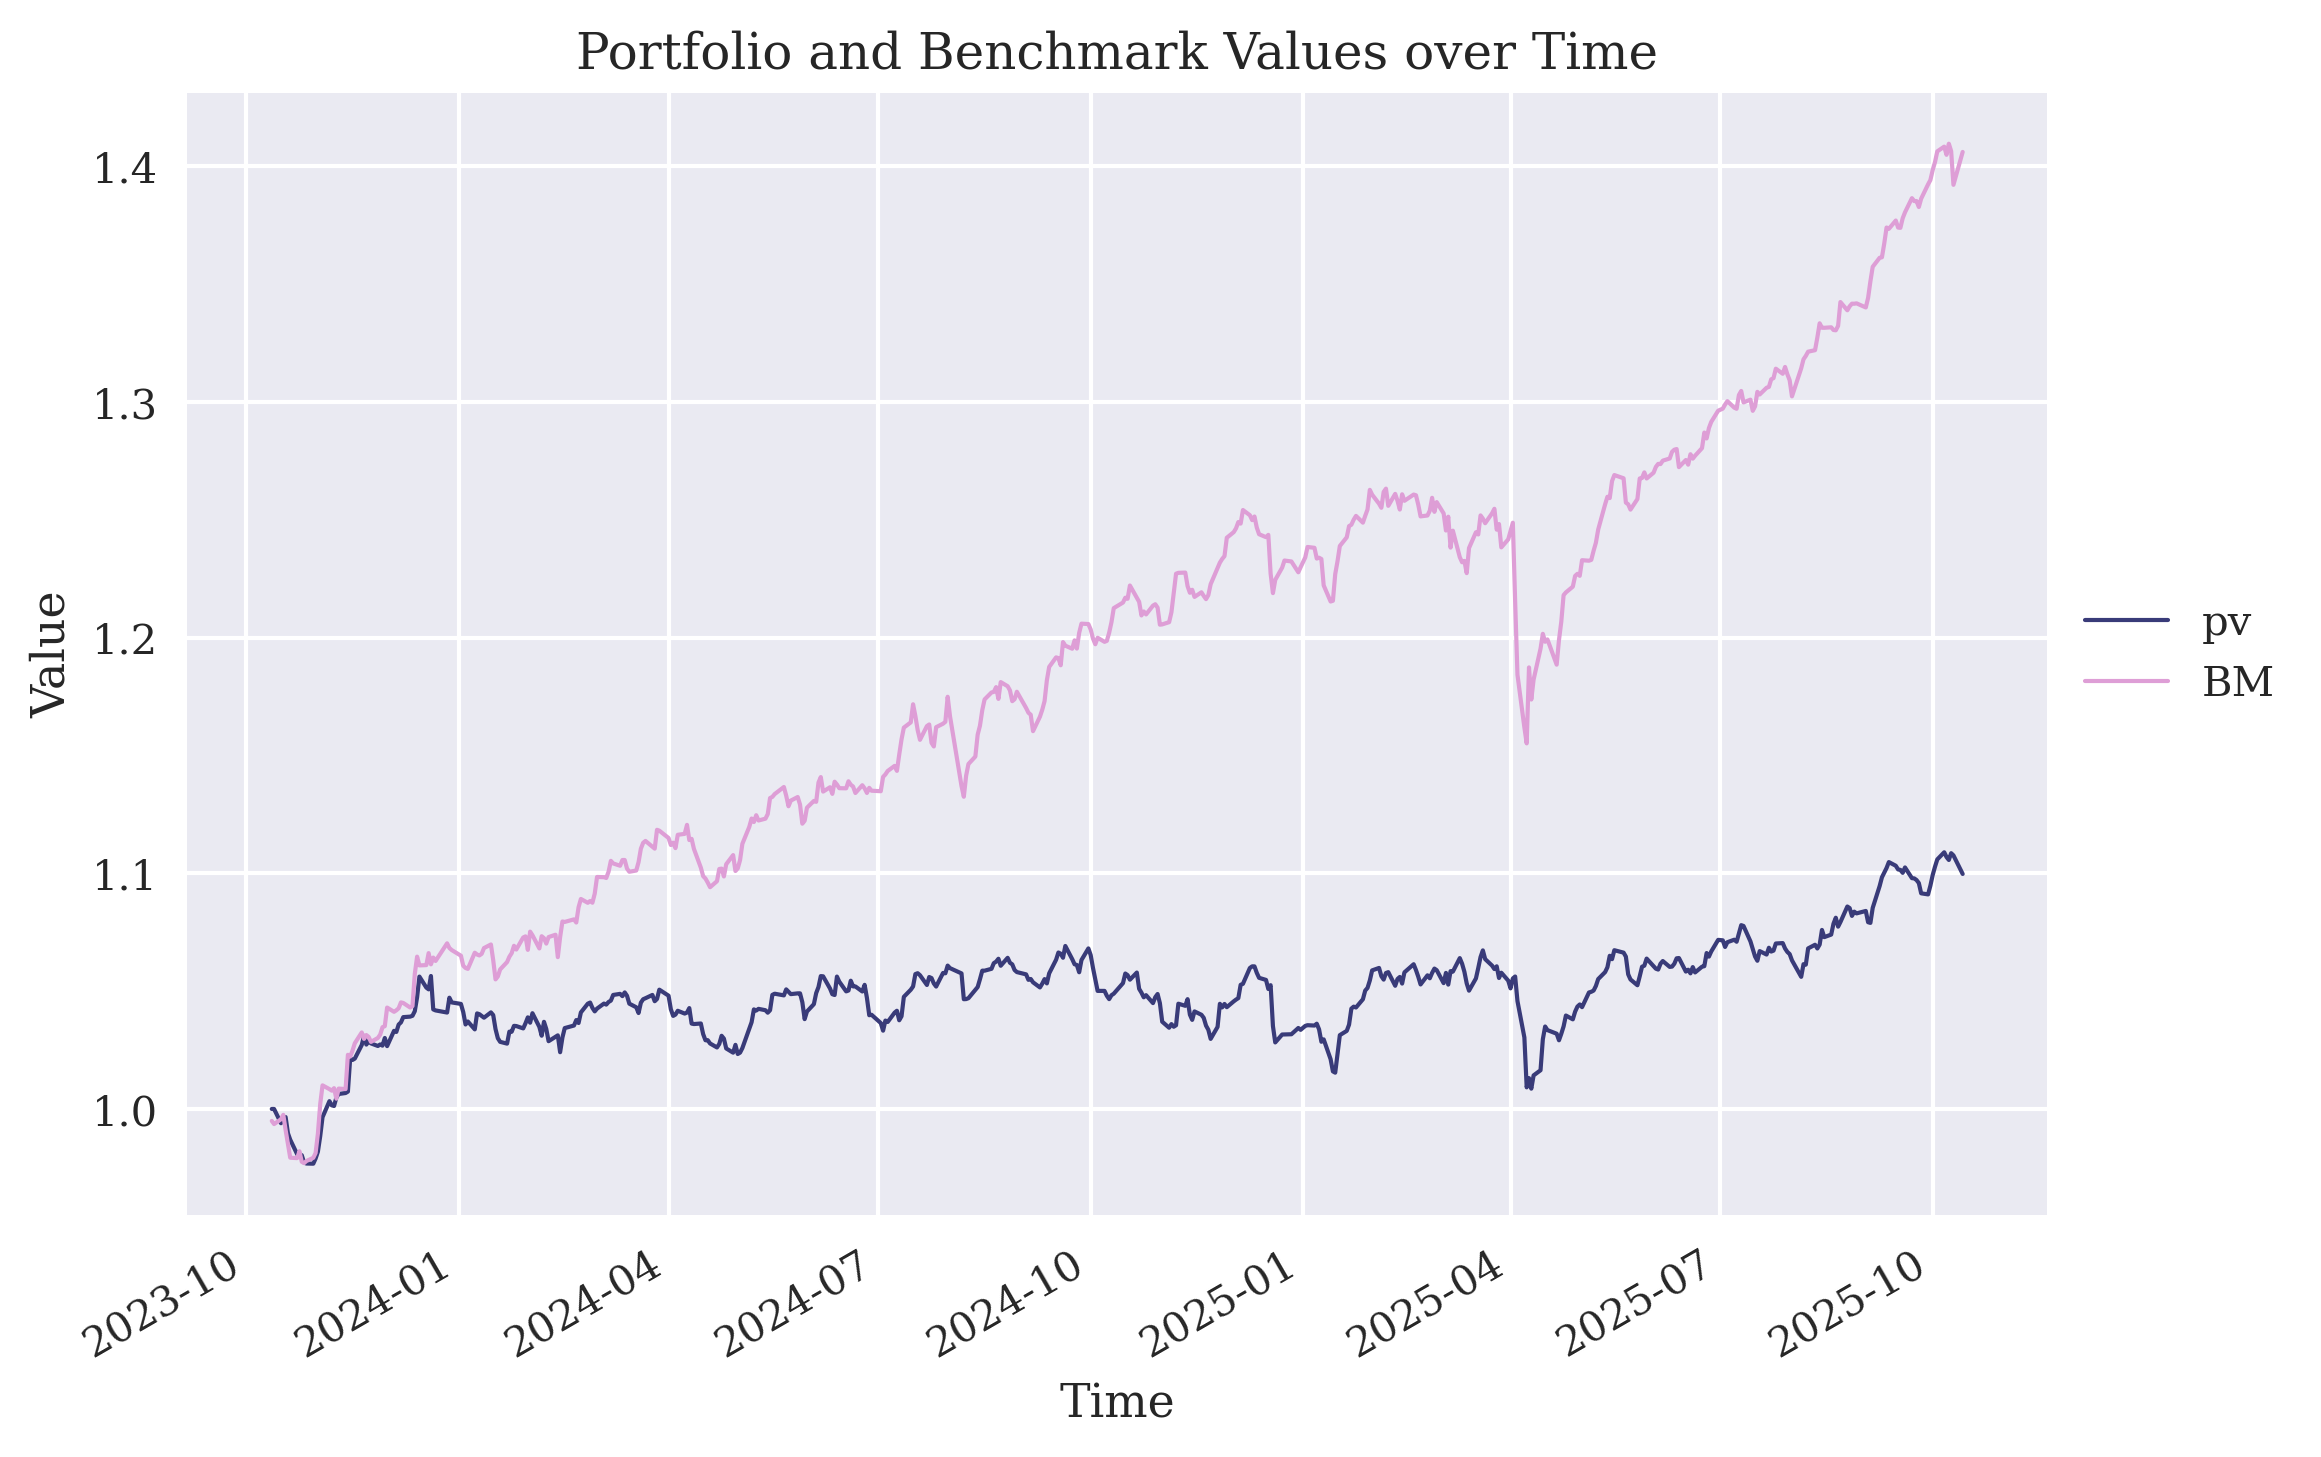

In [215]:
subset[['pv', 'BM']].plot(lw=1, title='Portfolio and Benchmark Values over Time', cmap='tab20b')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel('Value')
plt.xlabel('Time');

**As well as the Agent did managing the portfolio during this time period it still failed to beat the benchmark.**

### Testing Episode Sharpe Ratios
Let's take a closer look at the sharpe ratios of the testing episodes. As you can see Episode 91 is usually the most succesful episode in maximizing the portfolio's Sharpe Ratio.

In [219]:
sharpe_ratios = pd.DataFrame()

In [221]:
calculate_sr()

In [223]:
sharpe_ratios.round(2)

,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100
E-EM,-1.70,0.68,3.46,2.18,1.76,-0.34,1.77,1.53,3.81,2.79,5.03,1.73,-1.42,2.35,1.64,1.55,0.26,-0.51,0.18,2.33
E-GSC,-1.79,-0.04,0.50,1.22,0.88,-0.49,0.83,0.87,0.63,1.12,0.92,0.85,-1.65,1.17,0.81,0.68,0.16,-0.39,0.28,1.50
E-CLC,0.73,0.51,2.30,1.03,0.61,2.70,0.73,0.53,2.59,0.48,2.83,0.53,-0.39,0.12,1.08,0.72,0.64,0.56,0.64,0.25
E-US,0.39,1.69,2.30,1.76,1.32,1.76,1.47,1.42,2.09,1.64,2.62,1.34,0.25,1.86,1.75,1.27,2.16,1.47,2.21,2.22
E-CSC,-0.55,-0.21,1.12,2.25,1.22,1.44,1.95,1.93,1.38,1.58,1.68,1.94,-1.60,0.13,2.08,1.71,0.98,0.51,0.39,0.24
E-IE,-1.54,0.03,2.92,1.82,1.11,0.01,1.25,1.17,3.11,1.66,3.88,1.02,-1.16,2.02,1.38,1.05,-0.01,-0.21,0.33,2.57
D-CB,-3.61,-0.25,0.51,-0.59,2.03,-2.92,-0.29,-0.09,0.71,0.60,1.42,-0.16,-2.14,-0.51,-0.51,-0.30,0.53,2.06,0.81,0.11
A-CMM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pv,-1.79,-0.01,1.33,0.58,0.46,-1.39,-0.00,-0.15,1.33,0.23,1.71,-0.10,-1.73,0.35,-0.21,-0.08,0.28,0.21,0.50,0.85


Again because there is no change in price for the Money Market sleeve there is no return or standard deviation in the investing environement, hence the NaN.

#### Average Sharpe Ratio

In [227]:
sharpe_ratios.mean(axis=1)

E-EM     1.45467
E-GSC    0.40424
E-CLC    0.95834
E-US     1.65050
E-CSC    1.00784
E-IE     1.12085
D-CB    -0.12933
A-CMM        NaN
pv       0.11813
dtype: float64

## Who wants to be average?
Average is fine, but which was the best episode for the agent managing the portfolio in terms of maximizing the Sharpe ratio?

In [230]:
episode_with_best_sharpe = sharpe_ratios.idxmax(axis=1)['pv'] 
r_best = get_r(episode_with_best_sharpe)
r_best[weight_list].iloc[-1].round(2)

weight_E-EM     0.16
weight_E-GSC    0.33
weight_E-CLC    0.10
weight_E-US     0.00
weight_E-CSC    0.00
weight_E-IE     0.00
weight_D-CB     0.32
weight_A-CMM    0.09
Name: 2025-10-14 00:00:00, dtype: float64

#### Why use mean weights?
Because the agent tends towards the extreme ends of the bounds and the trading cost and administrative overhead of rebalancing daily is higher than people think, using an average to summarize a training Episode makes sense. Even applying penalties and enforcing bounds the Agent trades frequently. Taking the average asset weight is a more realisitic snapshot than the last weight at the end of a training or testing Episode, but you can try either by changing the line of code below.

In the end I decided to take both the last weights of the best testing Episode and the average machine learning weights which I saved to a variable above.

In [233]:
best_weights = r_best[weight_list].iloc[-1]  # Don't round here. Can try either .mean() or .iloc[-1]

In [235]:
last_best_ml_weights = tuple(best_weights.to_list()) 
training_port.pretty_weights(last_best_ml_weights)

+---------+--------+
| Holding | Weight |
+---------+--------+
|   E-EM  | 0.1621 |
|  E-GSC  |  0.33  |
|  E-CLC  | 0.098  |
|   E-US  |  0.0   |
|  E-CSC  |  0.0   |
|   E-IE  |  0.0   |
|   D-CB  | 0.3172 |
|  A-CMM  | 0.0928 |
+---------+--------+


## Testing Our Portfolios
Now that we've calculated mathematically precise mean-variance portfolios using a variety of means we can test them using the teasting data we set aside earlier.

In [241]:
symbols = testing_asset_returns.columns 
portfolio_name = str(last_year) + ' Efficient Portfolio'
testing_port = MVPortfolio(
                        bm_returns=bm_testing_returns,
                        comparison_weights_one=ml_average_weights,
                        portfolio_one_name='Average ML Weights',
                        comparison_weights_two=maximum_sharpe_weights,
                        portfolio_two_name='Training Period Efficient Portfolio',
                        comparison_weights_three=last_training_year_weights,
                        portfolio_three_name=portfolio_name,
                        comparison_weights_four=last_best_ml_weights,
                        portfolio_four_name='Last Best ML Weights',
                        comparison_weights_five=portfolio_five_weights,
                        portfolio_five_name=portfolio_five_name,
                        boundaries=bnds_used_in_training,
                        universe=testing_asset_returns,
                        holdings=symbols
                       )

Remember target asset class weights [0.6, 0.4, 0.0] can be overruled by bnds.
Current bnds are ((0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.0, 0.33), (0.19, 0.6), (0.01, 0.2))


### Visualizing and Testing Our Portfolios

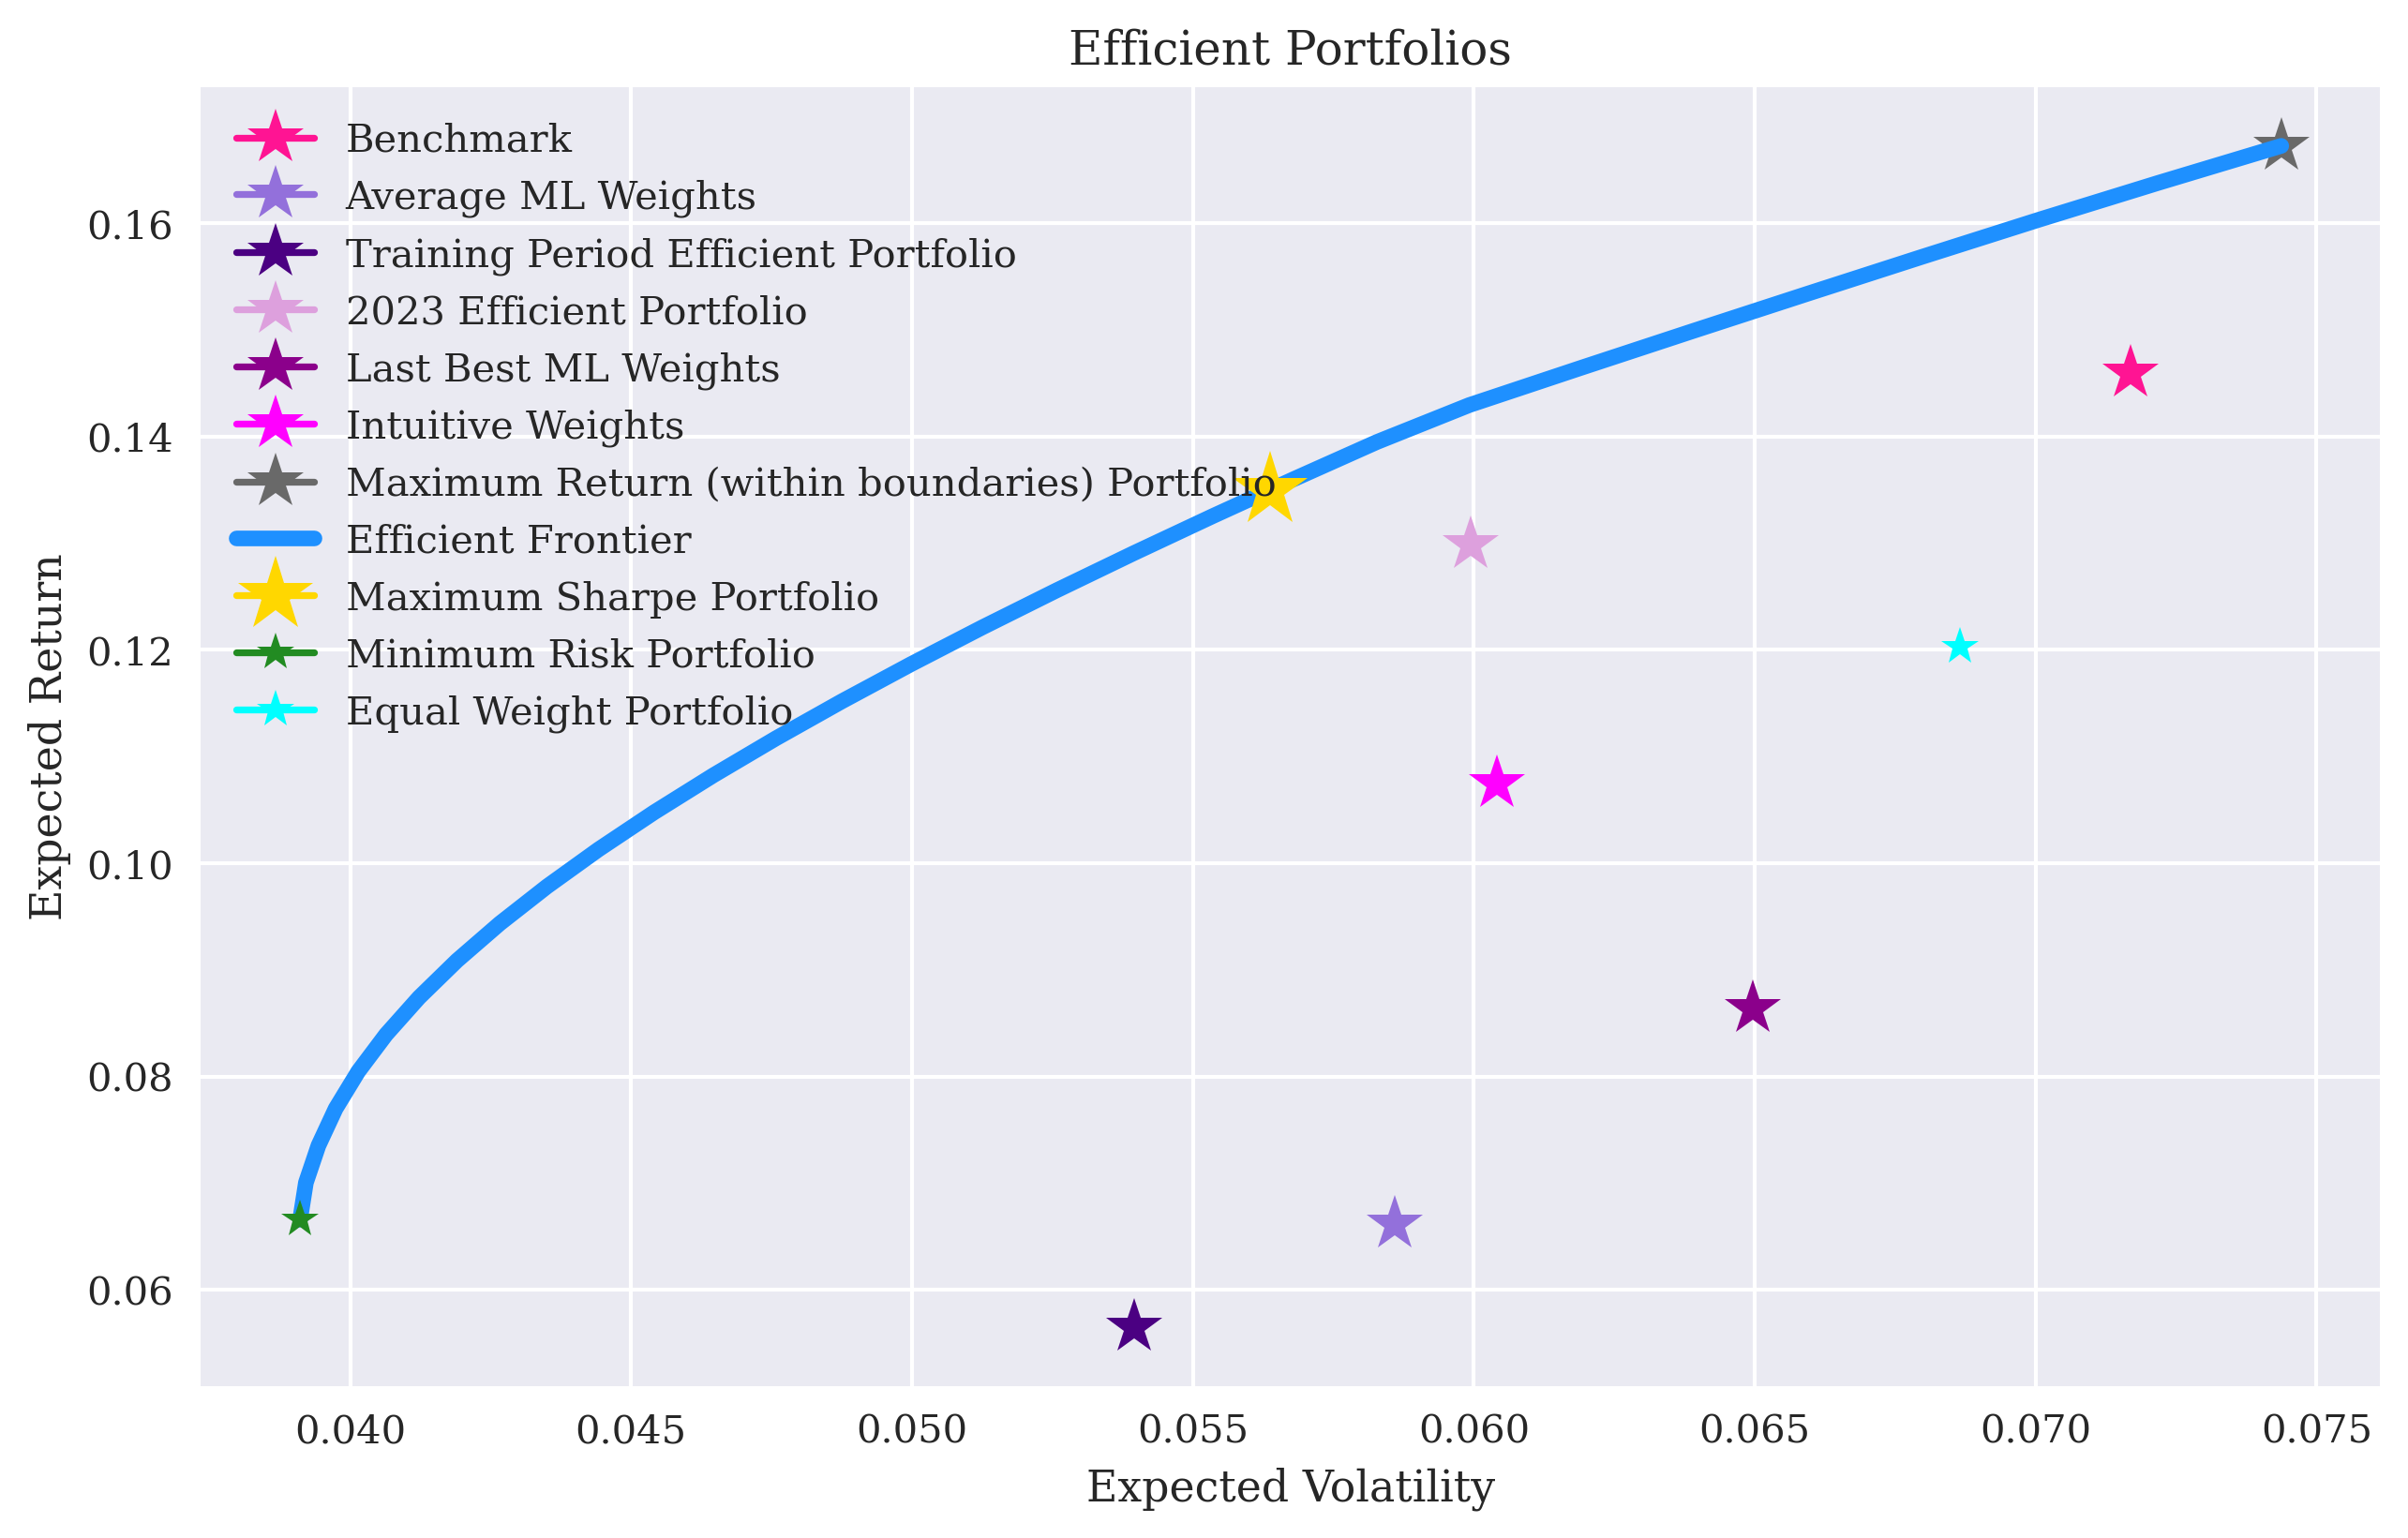

In [244]:
testing_port.visualize_efficient_frontier() 

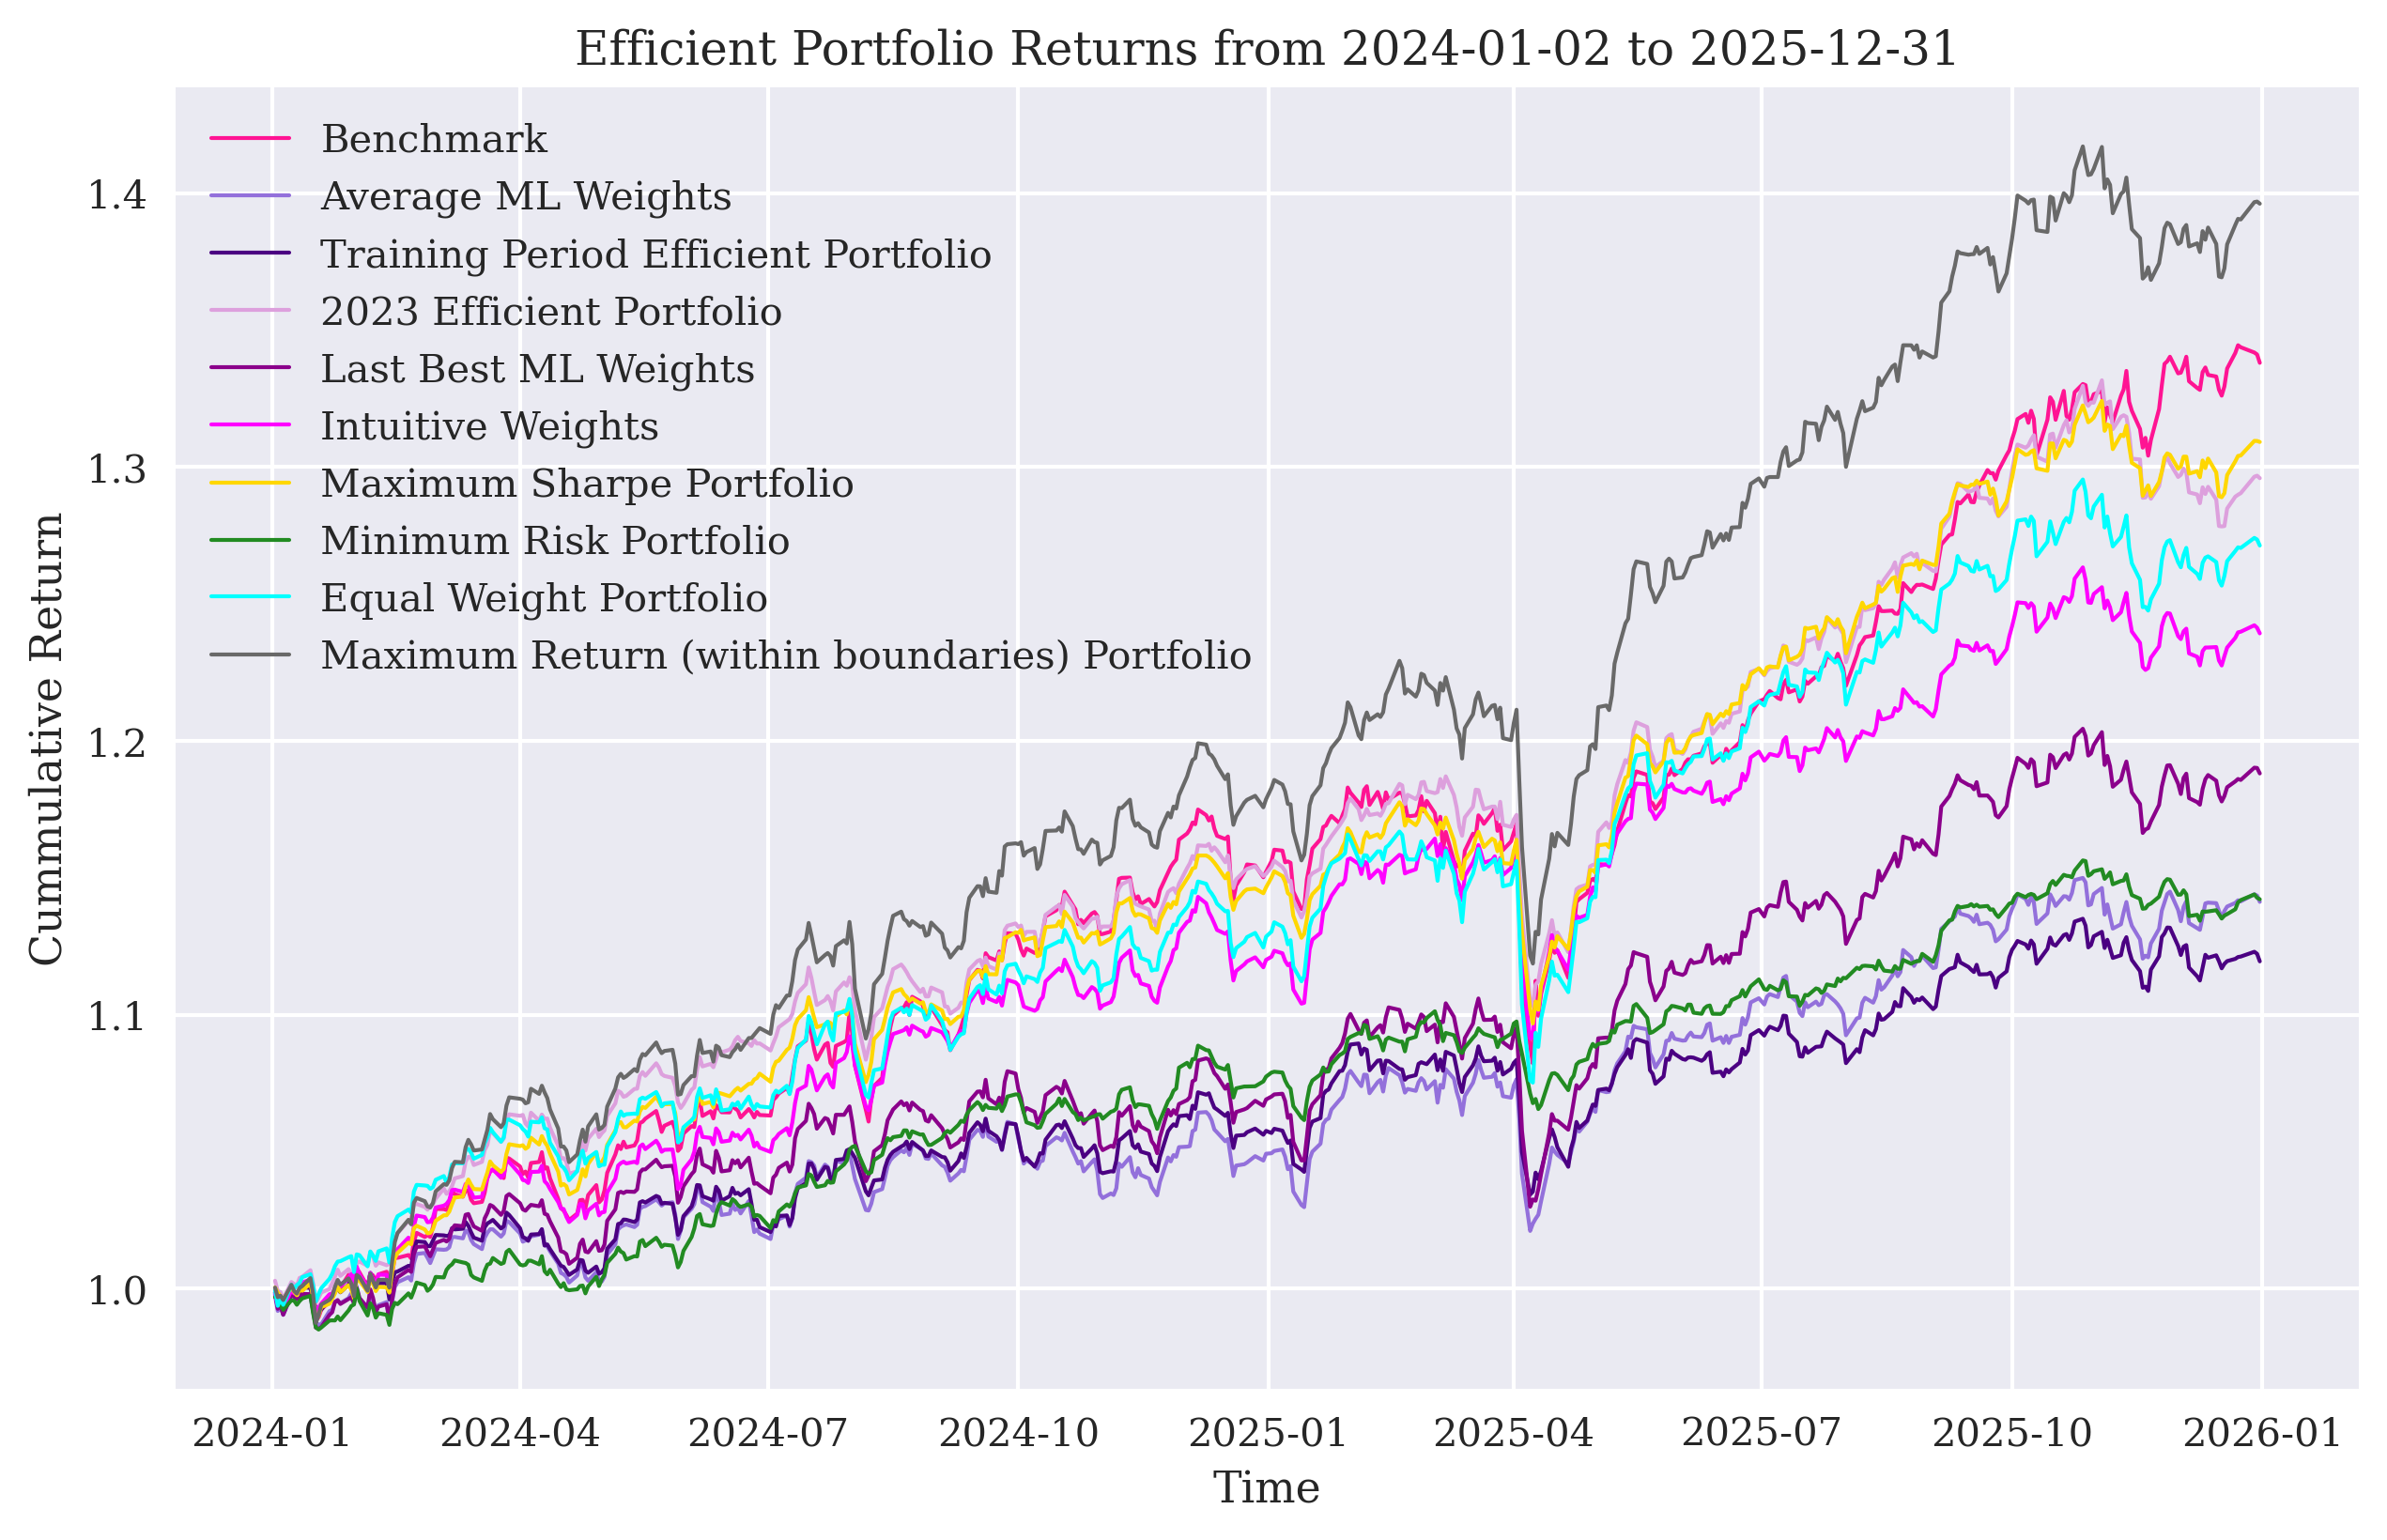

In [246]:
testing_port.visualize_portfolio_returns()

## Testing Period Summary
The benchmark did very well over this period of time, it is not unbeatable but you must take on a lot of volatility to exceed the performance of the benchmark. Outside the training period the machine learning weights did not perform well but neither did the Maximum Sharpe Portfolio from the training period which I labeled "Training Period Efficient Portfolio". The "2023 Efficient Portfolio" did better and even beat the equal weight portfolio by the virtue of being closer to the efficient frontier and having a greater cummulative return.

### Takeaways
- Training period performance or **past performance is no guarantee of future performance**.
- It is very difficult to beat a well chosen benchmark even with frequent rebalancing based on machine learning.
- If you are willing to take on more volatility it is possible to achieve higher than benchmark returns.

#### Maximum Sharpe Portfolio during Testing Period

In [251]:
testing_maximum_return_weights = testing_port.maximum_return_portfolio()
testing_port.pretty_weights(testing_maximum_return_weights)

+---------+--------+
| Holding | Weight |
+---------+--------+
|   E-EM  |  0.33  |
|  E-GSC  |  0.0   |
|  E-CLC  |  0.33  |
|   E-US  |  0.0   |
|  E-CSC  |  0.0   |
|   E-IE  |  0.14  |
|   D-CB  |  0.19  |
|  A-CMM  |  0.01  |
+---------+--------+


During the testing period you want to max out Emerging Market Equity which is one of our best performing equity portfolios. Canadian Large Cap equity is also maxed out. As the last two years have arguably been a bull market a minimum allocation to bonds and t-bills was optimal. International Equity is another equity portfolio that has performed well recently and historically at the firm.

In [849]:
# we can make a third portfolio using all the data log_returns and bm_log_returns but more metrics is also cool.
# Need to check this into GitHub and test in Google Collab too, but another night of coding is finished.